In [ ]:
# === [TFM_newcodes] redireccion de figuras a la carpeta ./figures/ ===
# Celda anadida automaticamente: cualquier figura guardada con un nombre
# de fichero simple (sin carpeta) se guarda dentro de ./figures/.
# Las rutas que ya incluyen una carpeta (p.ej. 'figures/...') se respetan.
import os as _os
import matplotlib.pyplot as _plt
from matplotlib.figure import Figure as _Figure
_os.makedirs('figures', exist_ok=True)
def _fig_redirect(fname):
    try:
        p = _os.fspath(fname)
    except TypeError:
        return fname  # objeto tipo fichero/buffer: no tocar
    if _os.path.dirname(p) == '':
        p = _os.path.join('figures', p)
    d = _os.path.dirname(p)
    if d:
        _os.makedirs(d, exist_ok=True)
    return p
if not getattr(_plt.savefig, '_tfm_patched', False):
    _orig_plt_savefig = _plt.savefig
    _orig_fig_savefig = _Figure.savefig
    def _plt_savefig(fname, *a, **k):
        return _orig_plt_savefig(_fig_redirect(fname), *a, **k)
    _plt_savefig._tfm_patched = True
    def _fig_savefig(self, fname, *a, **k):
        return _orig_fig_savefig(self, _fig_redirect(fname), *a, **k)
    _plt.savefig = _plt_savefig
    _Figure.savefig = _fig_savefig
savefig = _plt.savefig  # por si se usa savefig(...) directamente


# Temporal analysis of messages by channel (taking into consideration bias)

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import powerlaw
import textwrap
from lifelines import KaplanMeierFitter

In [2]:
# import dataset
df = pd.read_json("../../Datasets/vagarenfe.json") # Import data from Voluntarios de Valencia groupchat.

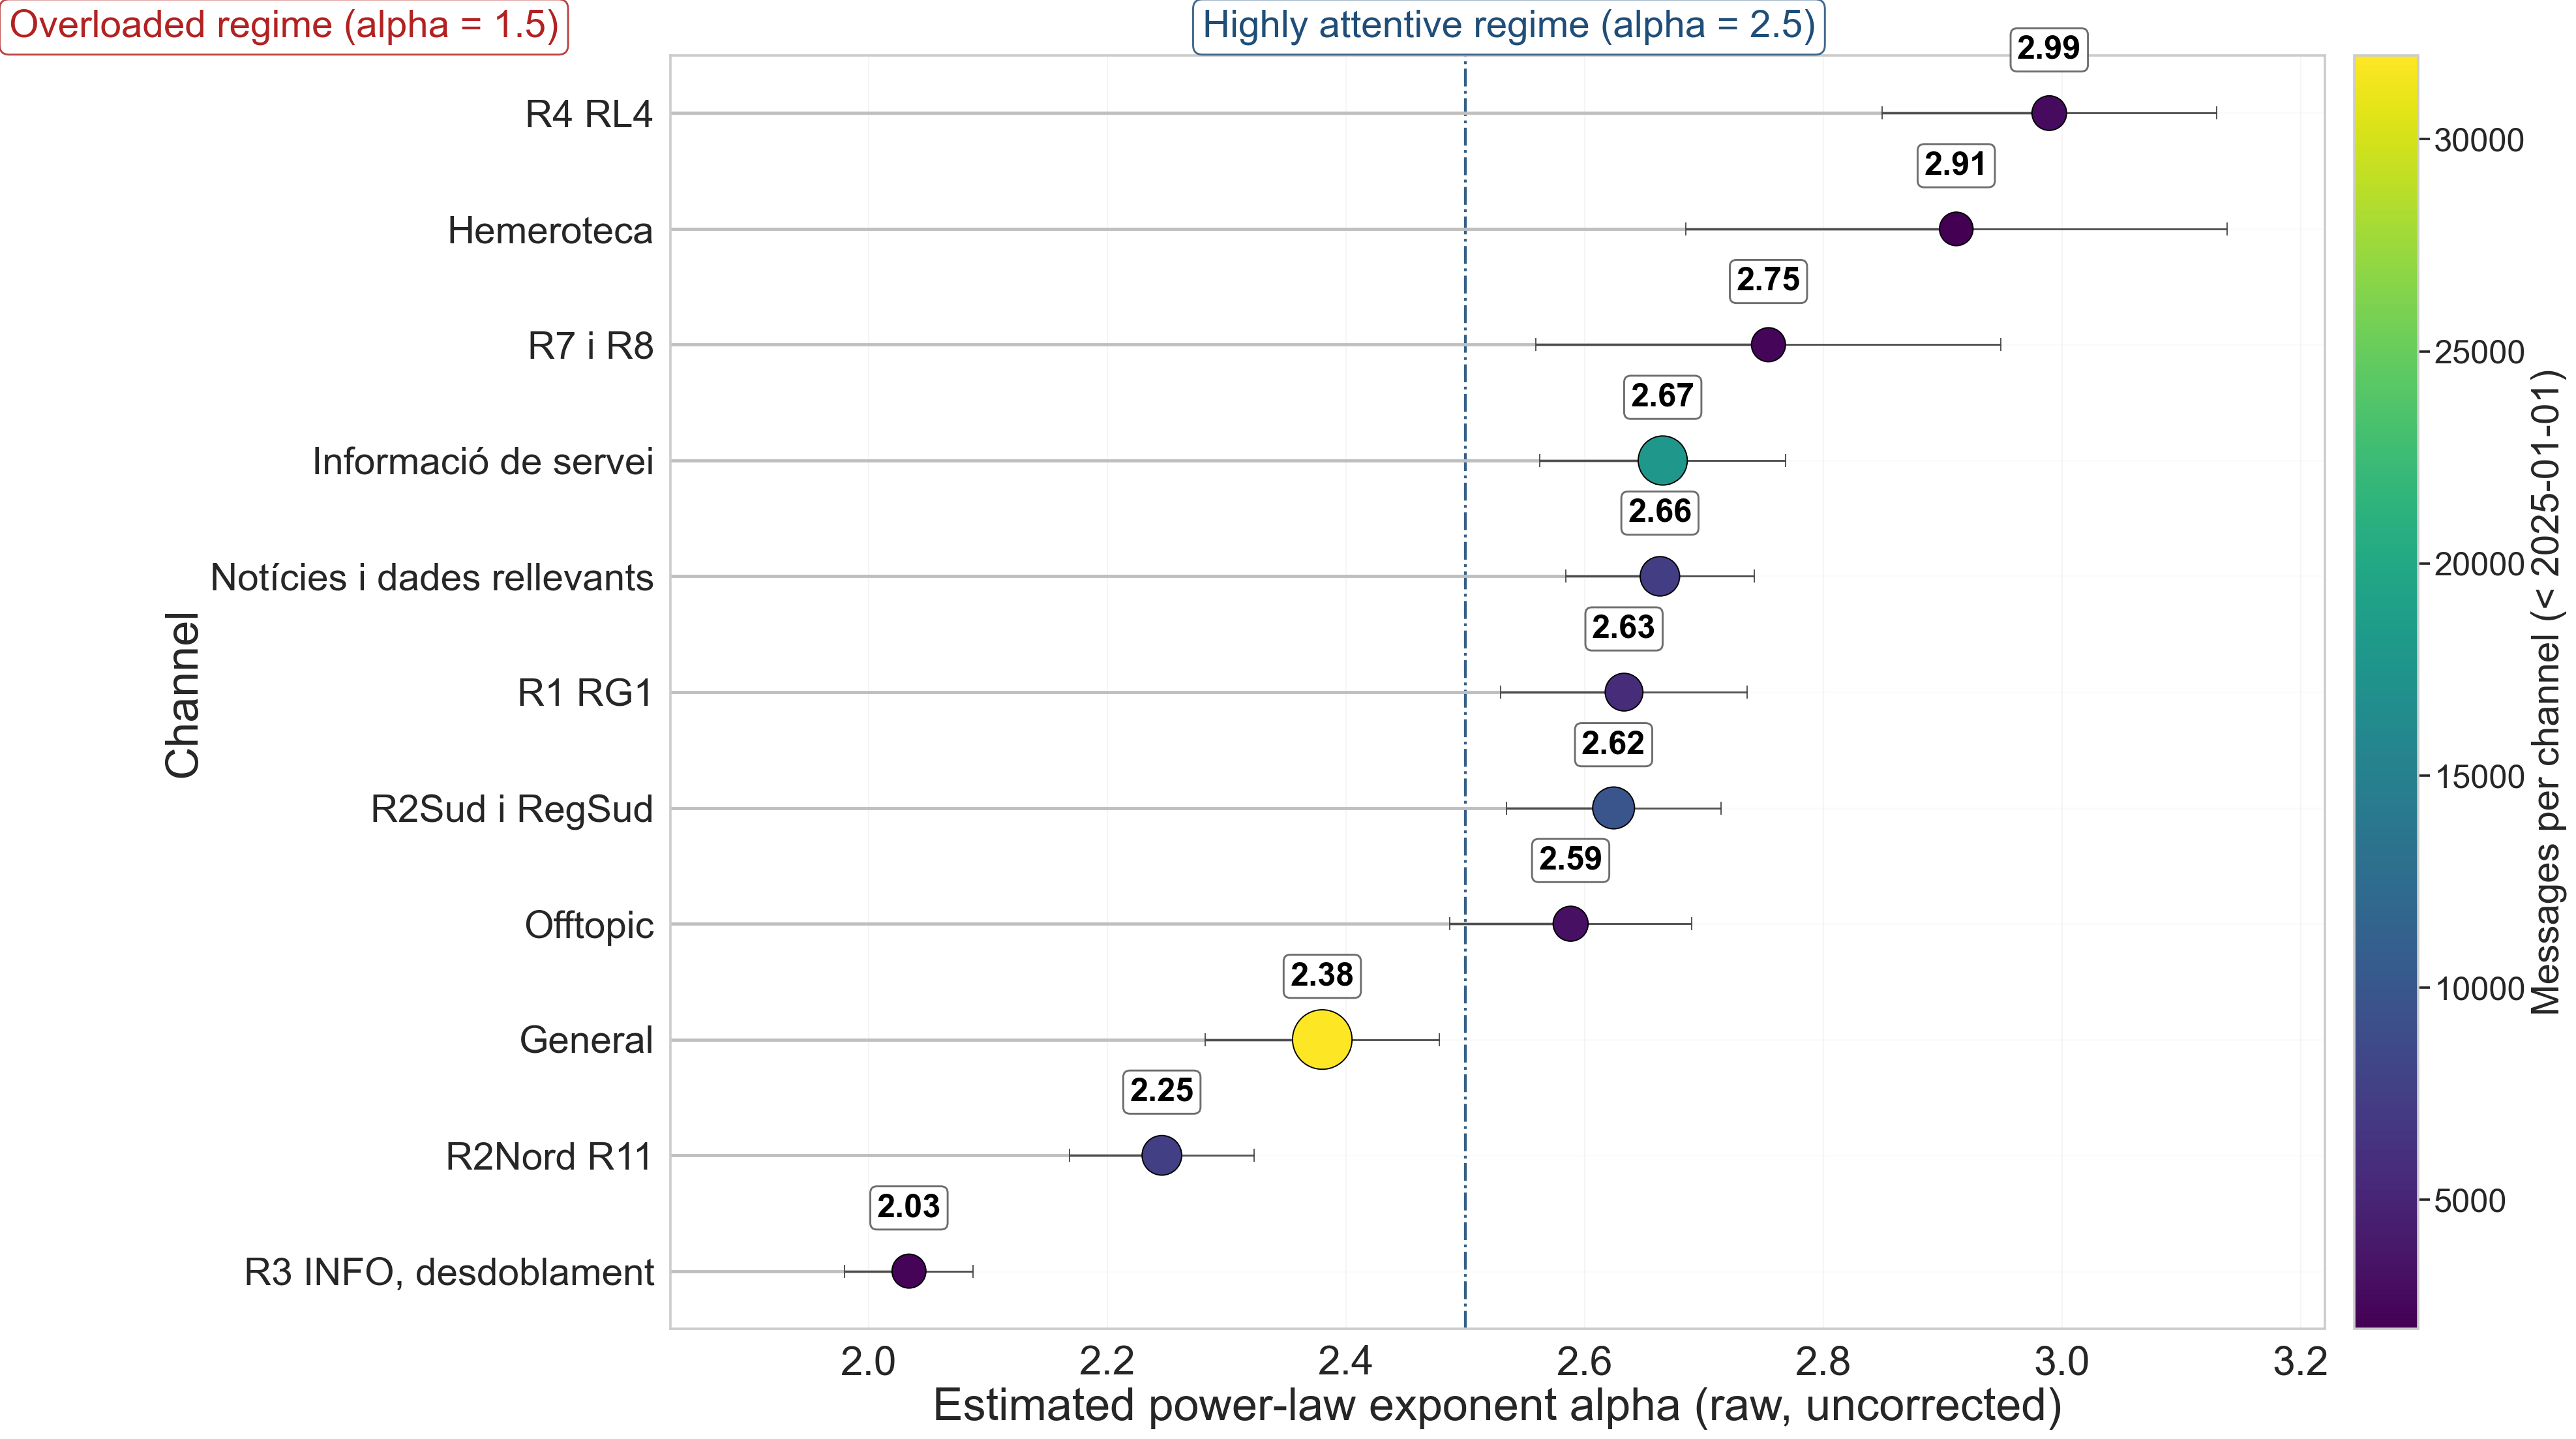

,channel,alpha,alpha_km,bias_sev,sigma,xmin,n_messages,n_waiting,n_tail
0,"R3 INFO, desdoblament",2.033975,2.306772,0.0147,0.053827,54014.0,2287,2245,369
1,R2Nord R11,2.245880,2.311896,0.0688,0.077118,44505.0,7498,6000,261
2,General,2.380272,2.608864,0.0112,0.098092,54613.0,31982,6000,198
3,Offtopic,2.588385,2.973151,0.0102,0.101478,125808.0,3176,3115,245
4,R2Sud i RegSud,2.624388,2.920508,0.0073,0.089967,35167.0,9735,6000,326
5,R1 RG1,2.633114,2.761832,0.0089,0.103287,46748.0,5624,5597,250
6,Notícies i dades rellevants,2.663193,3.011034,0.0062,0.079021,59869.0,7282,6000,443
7,Informació de servei,2.665573,2.878329,0.0059,0.102899,37789.0,17957,6000,262
8,R7 i R8,2.754136,2.847742,0.0394,0.194904,139566.0,2340,2333,81
9,Hemeroteca,2.911489,2.924950,0.0369,0.226852,239593.0,1945,1701,71


<Figure size 896x672 with 0 Axes>

In [3]:
# PL analysis: power-law exponents across channels (>1000 msgs), up to 2025-01-01.

# Ensure datetime
df_alpha = df.copy()
df_alpha['date'] = pd.to_datetime(df_alpha['date'], errors='coerce')
df_alpha = df_alpha.dropna(subset=['date', 'topic_name'])

cutoff_date = df_alpha['date'].max()
date_tz = df_alpha['date'].dt.tz


channel_sizes = df_alpha.groupby('topic_name').size().sort_values(ascending=False)
eligible_channels = channel_sizes[channel_sizes > 1000].index

results = []
for channel in eligible_channels:
    ch = df_alpha.loc[df_alpha['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]

    # KM correction (before subsampling — needs all IETs)
    T_seconds = (cutoff_date - ch['date'].iloc[0]).total_seconds()
    tau_fc    = max((cutoff_date - ch['date'].iloc[-1]).total_seconds(), 0.0)
    bias_sev  = waiting.max() / T_seconds

    iet_vals = waiting.values
    km_dur   = np.concatenate([iet_vals, iet_vals, [tau_fc]])
    km_obs   = np.concatenate([np.ones(len(iet_vals)), np.ones(len(iet_vals)), [0]])
    kmf = KaplanMeierFitter()
    kmf.fit(km_dur, event_observed=km_obs.astype(bool))

    if len(waiting) < 100:
        continue
    if len(waiting) > 6000:
        waiting = waiting.sample(6000, random_state=42).sort_values()

    try:
        fit   = powerlaw.Fit(waiting.values, discrete=True, verbose=False)
        pl    = fit.power_law
        alpha = float(getattr(pl, 'alpha', np.nan))
        sigma = float(getattr(pl, 'sigma', np.nan))
        xmin  = float(getattr(pl, 'xmin', np.nan))
        n_tail = int(np.sum(waiting.values >= xmin)) if np.isfinite(xmin) else np.nan

        # KM-corrected alpha via log-log regression on survival curve (PL)
        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask = (km_t >= xmin) & (km_s > 0) & (km_t > 0)
        if np.isfinite(xmin) and mask.sum() > 5:
            slope, _ = np.polyfit(np.log(km_t[mask]), np.log(km_s[mask]), 1)
            alpha_km = float(1.0 - slope)  # S(τ) ~ τ^{-(α-1)}
        else:
            alpha_km = np.nan

        if np.isfinite(alpha):
            results.append({
                'channel':    channel,
                'alpha':      alpha,
                'alpha_km':   alpha_km,
                'bias_sev':   round(bias_sev, 4),
                'sigma':      sigma if np.isfinite(sigma) else np.nan,
                'xmin':       xmin,
                'n_messages': int(channel_sizes[channel]),
                'n_waiting':  int(len(waiting)),
                'n_tail':     n_tail
            })
    except Exception as exc:
        print(f"Skipping channel: {channel} -> {exc}")

alpha_df = pd.DataFrame(results).sort_values('alpha', ascending=True).reset_index(drop=True)

if alpha_df.empty:
    raise ValueError('No valid alpha estimates could be computed.')

alpha_df['channel_label'] = alpha_df['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

# --- Poster: PL (raw, uncorrected) ---
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'axes.titlesize': 42, 'axes.labelsize': 36,
    'xtick.labelsize': 32, 'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_df['alpha'].min() - 0.2)
for i, row in alpha_df.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(alpha_df['n_messages'],
                  (alpha_df['n_messages'].min(), alpha_df['n_messages'].max()), (700, 2200))
scatter = ax.scatter(alpha_df['alpha'], np.arange(len(alpha_df)),
                     s=sizes, c=alpha_df['n_messages'], cmap='viridis',
                     edgecolor='black', linewidth=1.0, zorder=3)

valid_sigma = alpha_df['sigma'].notna()
ax.errorbar(alpha_df.loc[valid_sigma, 'alpha'], np.where(valid_sigma)[0],
            xerr=alpha_df.loc[valid_sigma, 'sigma'],
            fmt='none', ecolor='0.25', elinewidth=1.5, capsize=5, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_df) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25'))
ax.text(2.28, len(alpha_df) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25'))

ax.set_yticks(np.arange(len(alpha_df)))
ax.set_yticklabels(alpha_df['channel_label'], fontsize=30)
ax.set_xlabel('Estimated power-law exponent alpha (raw, uncorrected)', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (< 2025-01-01)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_df.iterrows():
    ax.annotate(f"{row['alpha']:.2f}", (row['alpha'], i),
                xytext=(0, 38), textcoords='offset points',
                va='bottom', ha='center', fontsize=26, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.savefig('alpha_pl_poster.svg', format='svg', bbox_inches='tight')

alpha_df[['channel', 'alpha', 'alpha_km', 'bias_sev', 'sigma', 'xmin', 'n_messages', 'n_waiting', 'n_tail']]

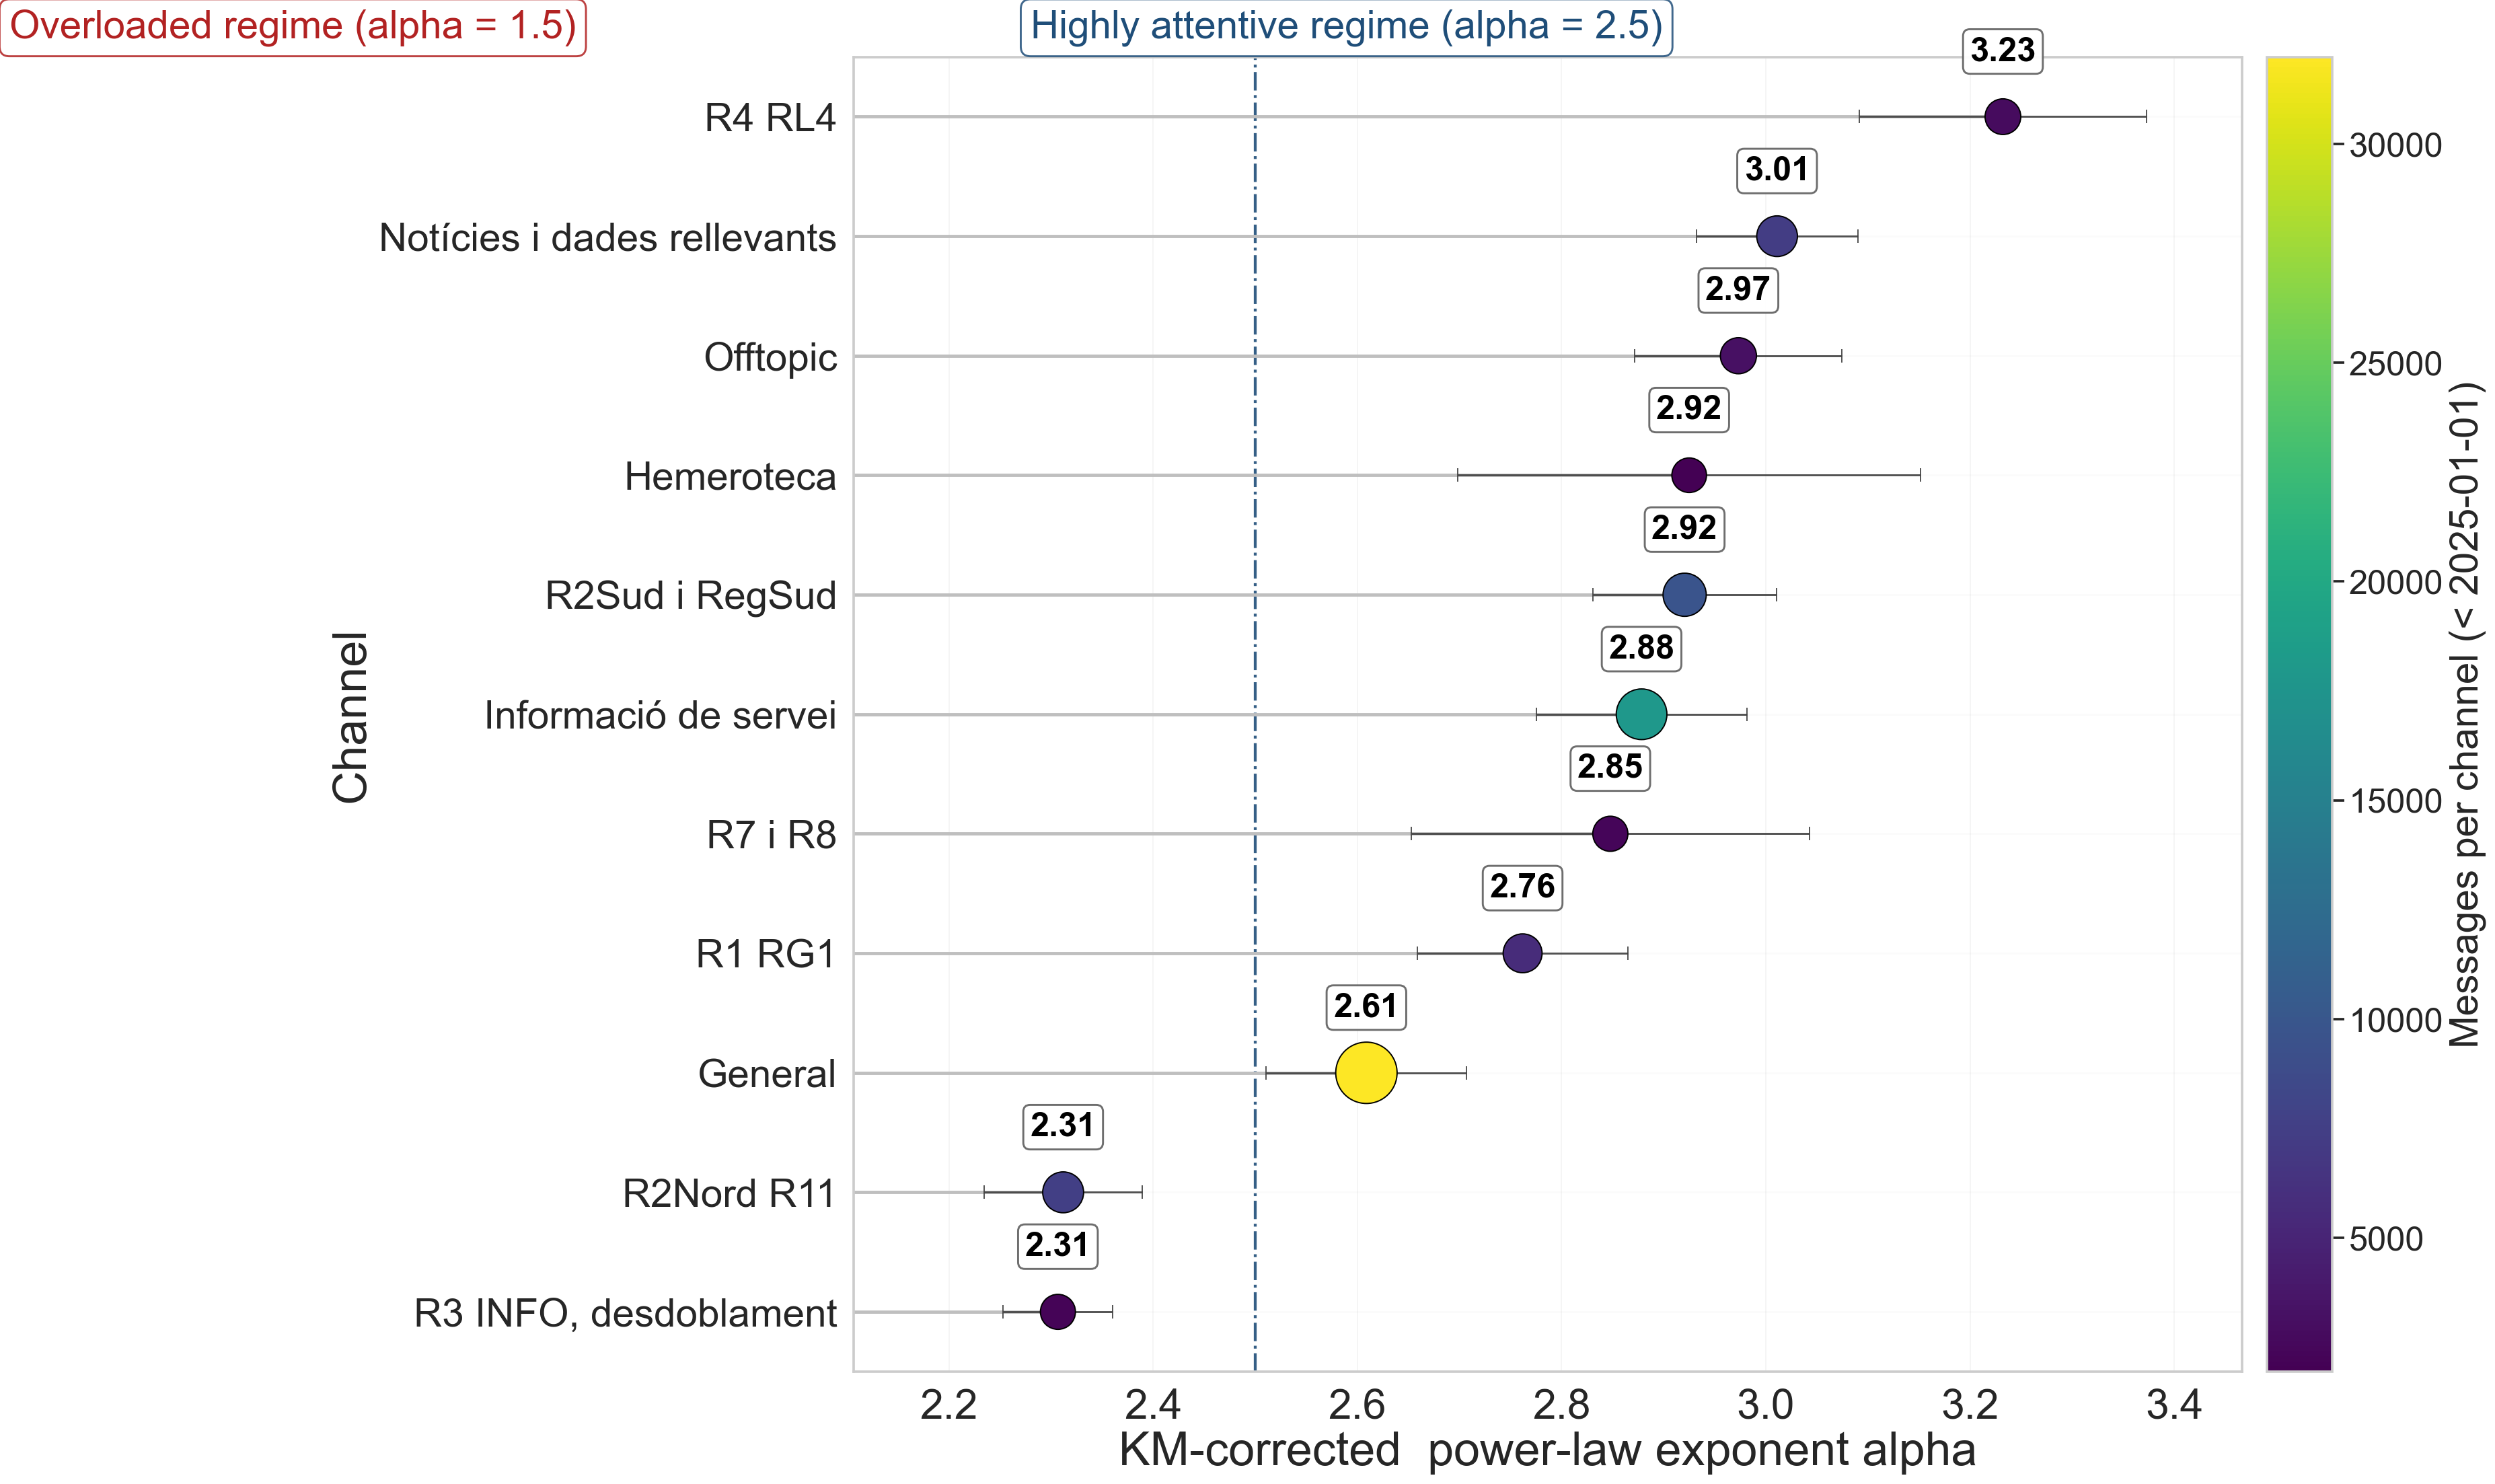

<Figure size 896x672 with 0 Axes>

In [4]:

    # Same poster-style lollipop chart but using KM-corrected alpha (finite-size-bias corrected)

# Drop rows where alpha_km is NaN (fit didn't converge)
alpha_km_df = alpha_df.dropna(subset=['alpha_km']).sort_values('alpha_km', ascending=True).reset_index(drop=True)
alpha_km_df['channel_label'] = alpha_km_df['channel'].apply(
    lambda s: __import__('textwrap').shorten(str(s), width=46, placeholder='...')
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'axes.titlesize': 42,
    'axes.labelsize': 36,
    'xtick.labelsize': 32,
    'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_km_df['alpha_km'].min() - 0.2)
for i, row in alpha_km_df.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_km'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(
    alpha_km_df['n_messages'],
    (alpha_km_df['n_messages'].min(), alpha_km_df['n_messages'].max()),
    (700, 2200)
)

scatter = ax.scatter(
    alpha_km_df['alpha_km'],
    np.arange(len(alpha_km_df)),
    s=sizes,
    c=alpha_km_df['n_messages'],
    cmap='viridis',
    edgecolor='black',
    linewidth=1.0,
    zorder=3
)

# Uncertainty bars: reuse sigma from raw fit (same xmin region)
valid_sigma = alpha_km_df['sigma'].notna()
ax.errorbar(
    alpha_km_df.loc[valid_sigma, 'alpha_km'],
    np.where(valid_sigma)[0],
    xerr=alpha_km_df.loc[valid_sigma, 'sigma'],
    fmt='none',
    ecolor='0.25',
    elinewidth=1.5,
    capsize=5,
    zorder=2,
    alpha=0.9
)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)

ax.text(
    1.28, len(alpha_km_df) - 0.1, 'Overloaded regime (alpha = 1.5)',
    color='#B22222', fontsize=30, va='top', ha='left',
    bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25')
)
ax.text(
    2.28, len(alpha_km_df) - 0.1, 'Highly attentive regime (alpha = 2.5)',
    color='#1F4E79', fontsize=30, va='top', ha='left',
    bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25')
)

ax.set_yticks(np.arange(len(alpha_km_df)))
ax.set_yticklabels(alpha_km_df['channel_label'], fontsize=30)
ax.set_xlabel('KM-corrected  power-law exponent alpha', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (< 2025-01-01)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_km_df.iterrows():
    ax.annotate(
        f"{row['alpha_km']:.2f}",
        (row['alpha_km'], i),
        xytext=(0, 38),
        textcoords='offset points',
        va='bottom', ha='center',
        fontsize=26, color='black', fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2')
    )

plt.tight_layout()
plt.show()
plt.savefig('alpha_km_comparison_poster_normal.svg', format='svg', bbox_inches='tight')


## Finite size bias comparison

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


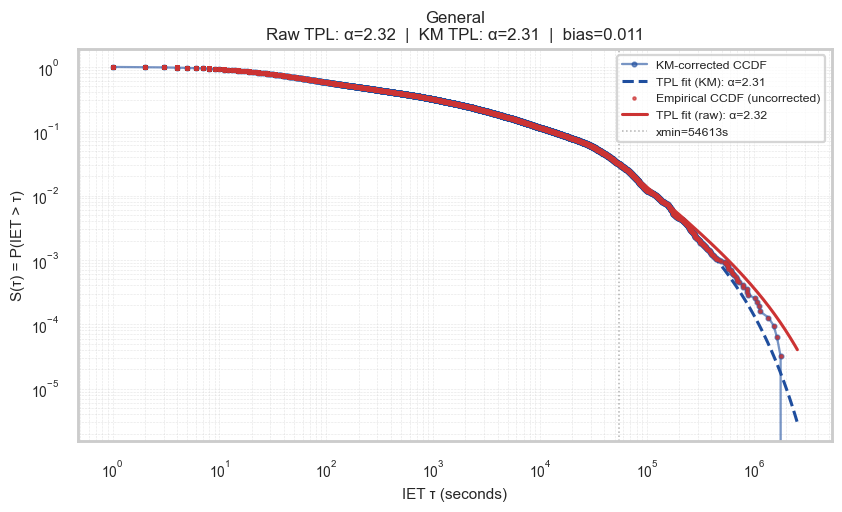

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


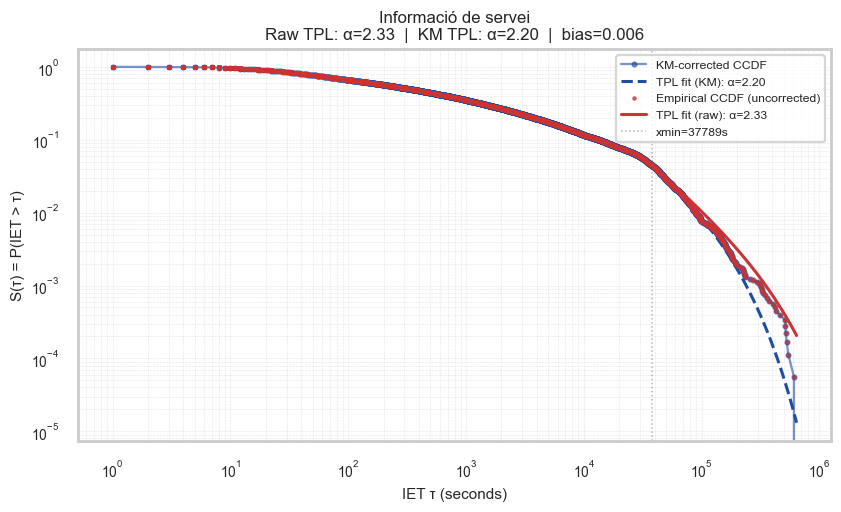

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


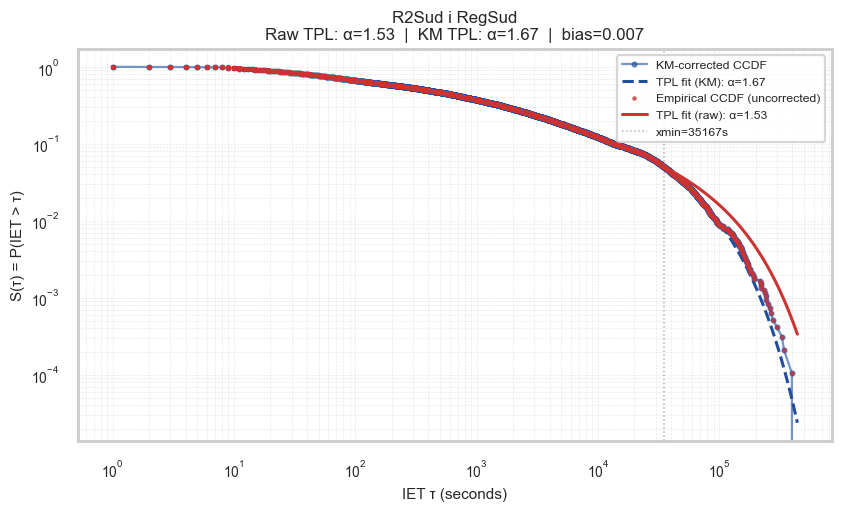

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


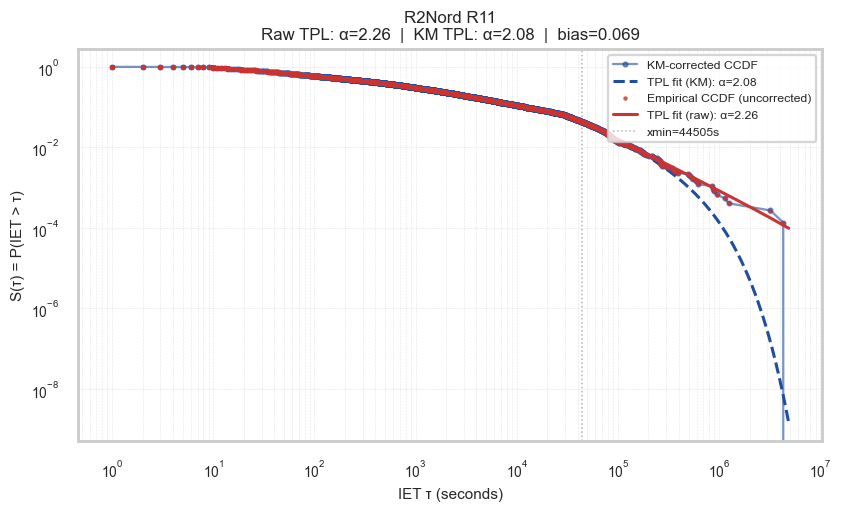

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


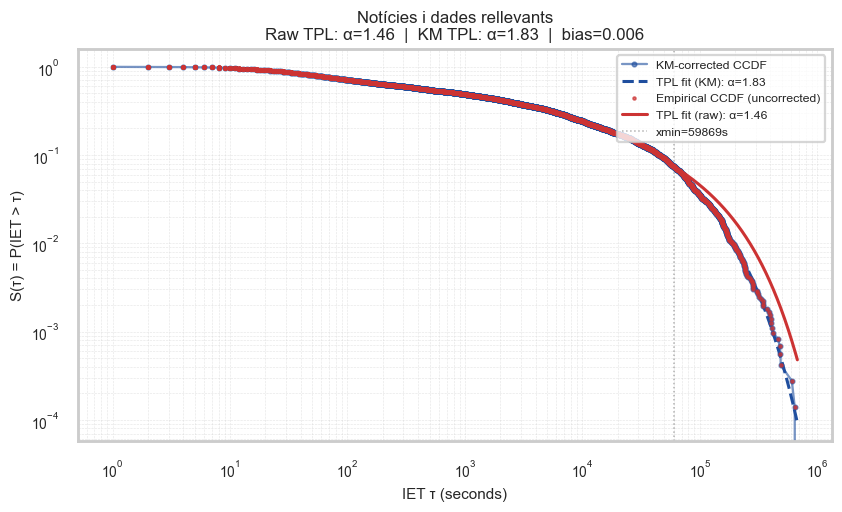

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


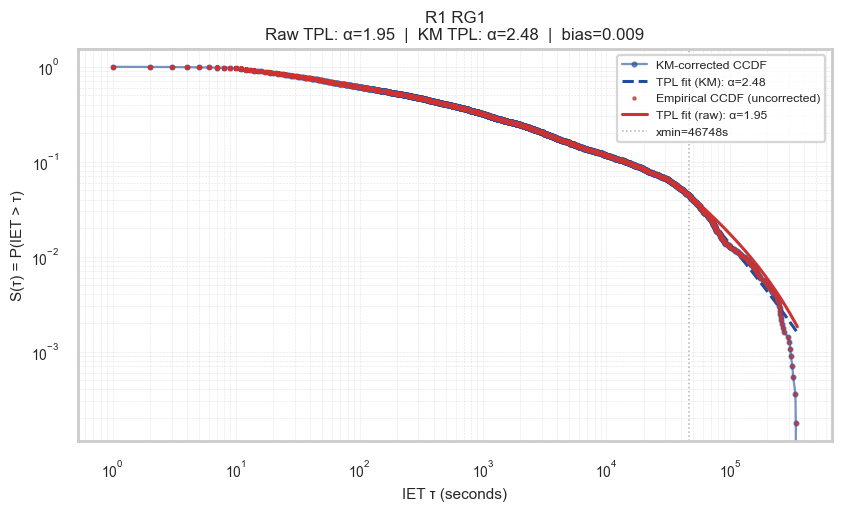

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


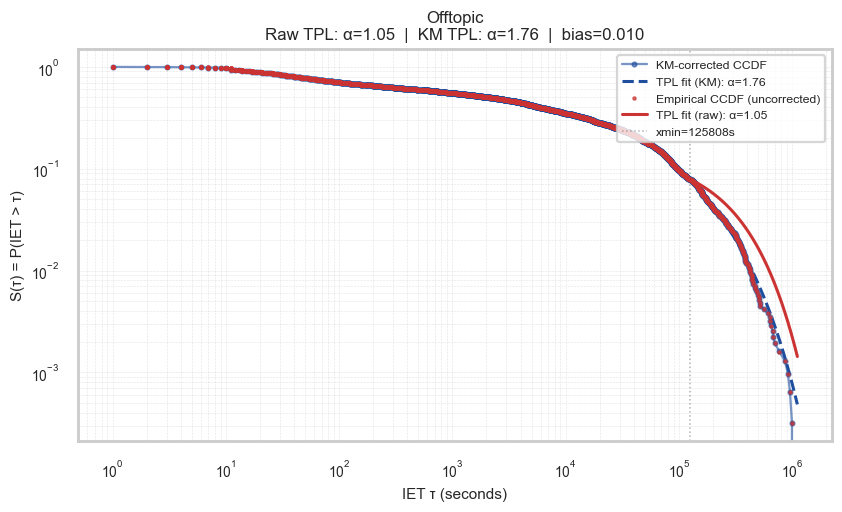

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


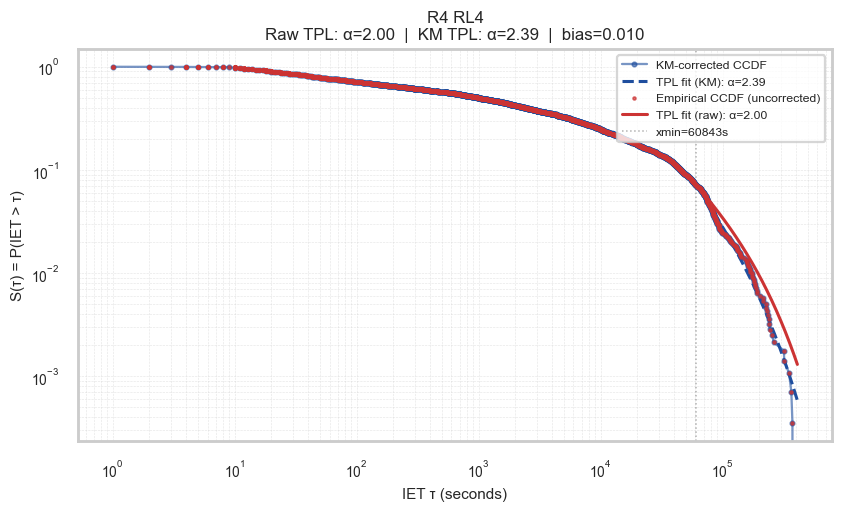

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


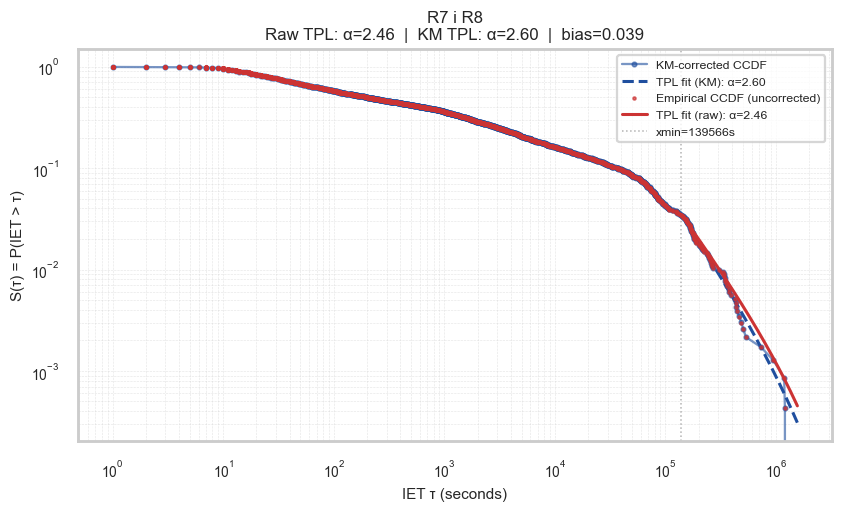

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


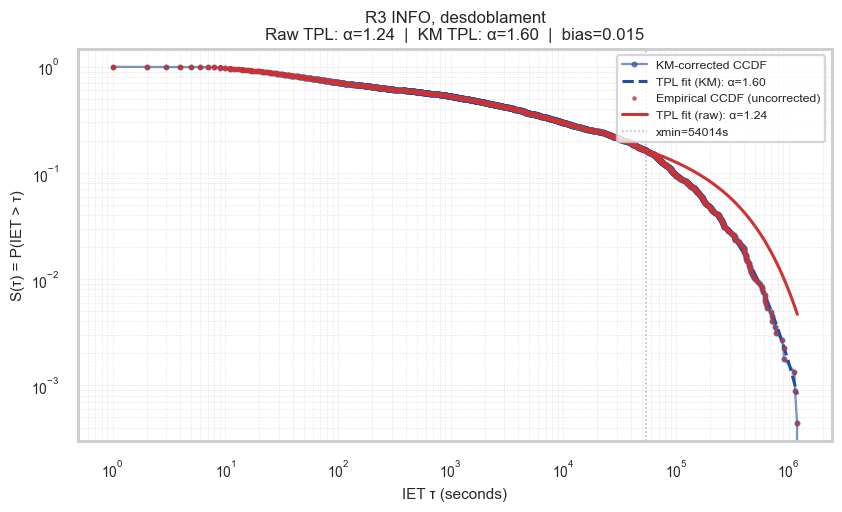

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


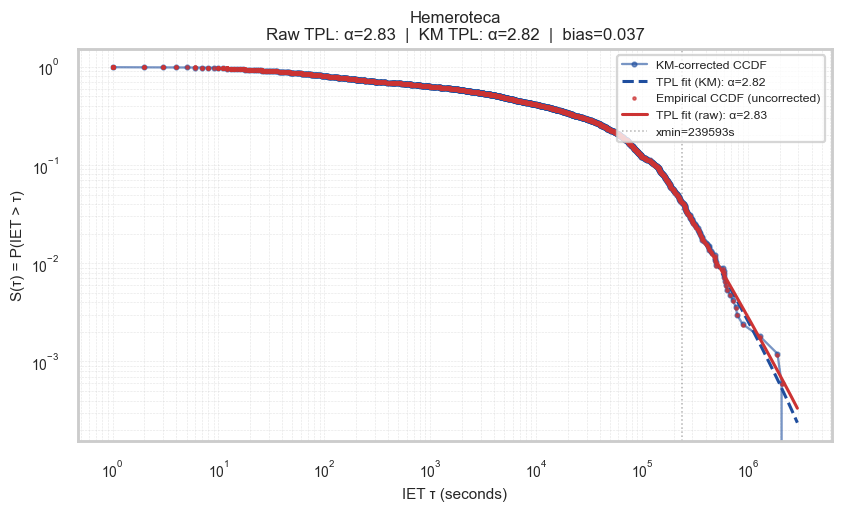

In [5]:
# data by channel: CCDF taking into account finite size bias with KM correction and not
from scipy.optimize import curve_fit

for channel in eligible_channels:
    results_channel = alpha_df[alpha_df['channel'] == channel]
    if results_channel.empty:
        continue

    ch = df_alpha.loc[df_alpha['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]
    if len(waiting) < 20:
        continue

    iet_vals = waiting.values
    xmin_val = float(results_channel['xmin'].values[0])
    alpha_km_val = float(results_channel['alpha_km'].values[0])
    bias = float(results_channel['bias_sev'].values[0])

    # --- KM correction ---
    tau_fc = max((cutoff_date - ch['date'].iloc[-1]).total_seconds(), 0.0)
    km_dur = np.concatenate([iet_vals, iet_vals, [tau_fc]])
    km_obs = np.concatenate([np.ones(len(iet_vals)), np.ones(len(iet_vals)), [0]])
    kmf = KaplanMeierFitter()
    kmf.fit(km_dur, event_observed=km_obs.astype(bool))
    km_t = kmf.survival_function_.index.values
    km_s = kmf.survival_function_['KM_estimate'].values

    # --- Empirical CCDF (uncorrected) ---
    sorted_iet = np.sort(iet_vals)
    n = len(sorted_iet)
    emp_surv = (n - np.arange(1, n + 1)) / n
    emp_mask = emp_surv > 0
    s_at_xmin_emp = (iet_vals >= xmin_val).sum() / n

    # --- Truncated power-law fit to uncorrected data ---
    fit_raw = powerlaw.Fit(iet_vals, xmin=xmin_val, discrete=True, verbose=False)
    tpl_raw = fit_raw.truncated_power_law
    alpha_tpl = tpl_raw.alpha
    Lambda_tpl = tpl_raw.parameter2

    # --- Truncated power-law fit to KM-corrected tail ---
    mask_km = (km_t >= xmin_val) & (km_s > 0) & (km_t > 0)
    alpha_tpl_km = np.nan
    Lambda_tpl_km = np.nan
    if mask_km.sum() > 5:
        km_t_tail = km_t[mask_km]
        km_s_norm = km_s[mask_km] / km_s[mask_km][0]

        def tpl_surv(t, alpha, lam):
            return (t / xmin_val) ** (-(alpha - 1)) * np.exp(-(t - xmin_val) * lam)

        try:
            popt, _ = curve_fit(
                tpl_surv, km_t_tail, km_s_norm,
                p0=[max(alpha_km_val, 1.01), 1.0 / iet_vals.max()],
                bounds=([1.001, 0.0], [20.0, np.inf]),
                maxfev=10000
            )
            alpha_tpl_km, Lambda_tpl_km = popt
        except Exception:
            pass

    t_fit = np.logspace(np.log10(xmin_val), np.log10(sorted_iet.max()), 300)

    # Use rc_context to isolate font sizes from the poster cell above
    with plt.rc_context({
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 8,
        'figure.dpi': 110,
    }):
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title(
            f"{channel}\n"
            f"Raw TPL: α={alpha_tpl:.2f}  |  KM TPL: α={alpha_tpl_km:.2f}  |  bias={bias:.3f}"
        )
        ax.set_xlabel('IET τ (seconds)')
        ax.set_ylabel('S(τ) = P(IET > τ)')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', ls='--', lw=0.4, alpha=0.5)

        # --- Plot KM first (background) ---
        mask_pos = km_t > 0
        ax.plot(km_t[mask_pos], km_s[mask_pos],
                'o-', color='#1F4E9E', markersize=3, lw=1.5, alpha=0.6,
                label='KM-corrected CCDF', zorder=2)

        if not np.isnan(alpha_tpl_km) and not np.isnan(Lambda_tpl_km):
            s_at_xmin_km = km_s[mask_km][0]
            s_fit_km = ((t_fit / xmin_val) ** (-(alpha_tpl_km - 1))
                        * np.exp(-(t_fit - xmin_val) * Lambda_tpl_km)
                        * s_at_xmin_km)
            ax.plot(t_fit, s_fit_km, '--', color='#1F4E9E', lw=2,
                    label=f'TPL fit (KM): α={alpha_tpl_km:.2f}', zorder=3)

        # --- Plot empirical on top (foreground) ---
        ax.plot(sorted_iet[emp_mask], emp_surv[emp_mask],
                '.', color='#CC3333', markersize=4, alpha=0.7,
                label='Empirical CCDF (uncorrected)', zorder=4)

        s_fit_raw = ((t_fit / xmin_val) ** (-(alpha_tpl - 1))
                     * np.exp(-(t_fit - xmin_val) * Lambda_tpl)
                     * s_at_xmin_emp)
        ax.plot(t_fit, s_fit_raw, '-', color='#CC3333', lw=2,
                label=f'TPL fit (raw): α={alpha_tpl:.2f}', zorder=5)

        ax.axvline(xmin_val, color='gray', lw=1, ls=':', alpha=0.6,
                   label=f'xmin={xmin_val:.0f}s', zorder=1)
        ax.legend(loc='upper right')
        plt.tight_layout()
        plt.show()


### Truncated power law

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

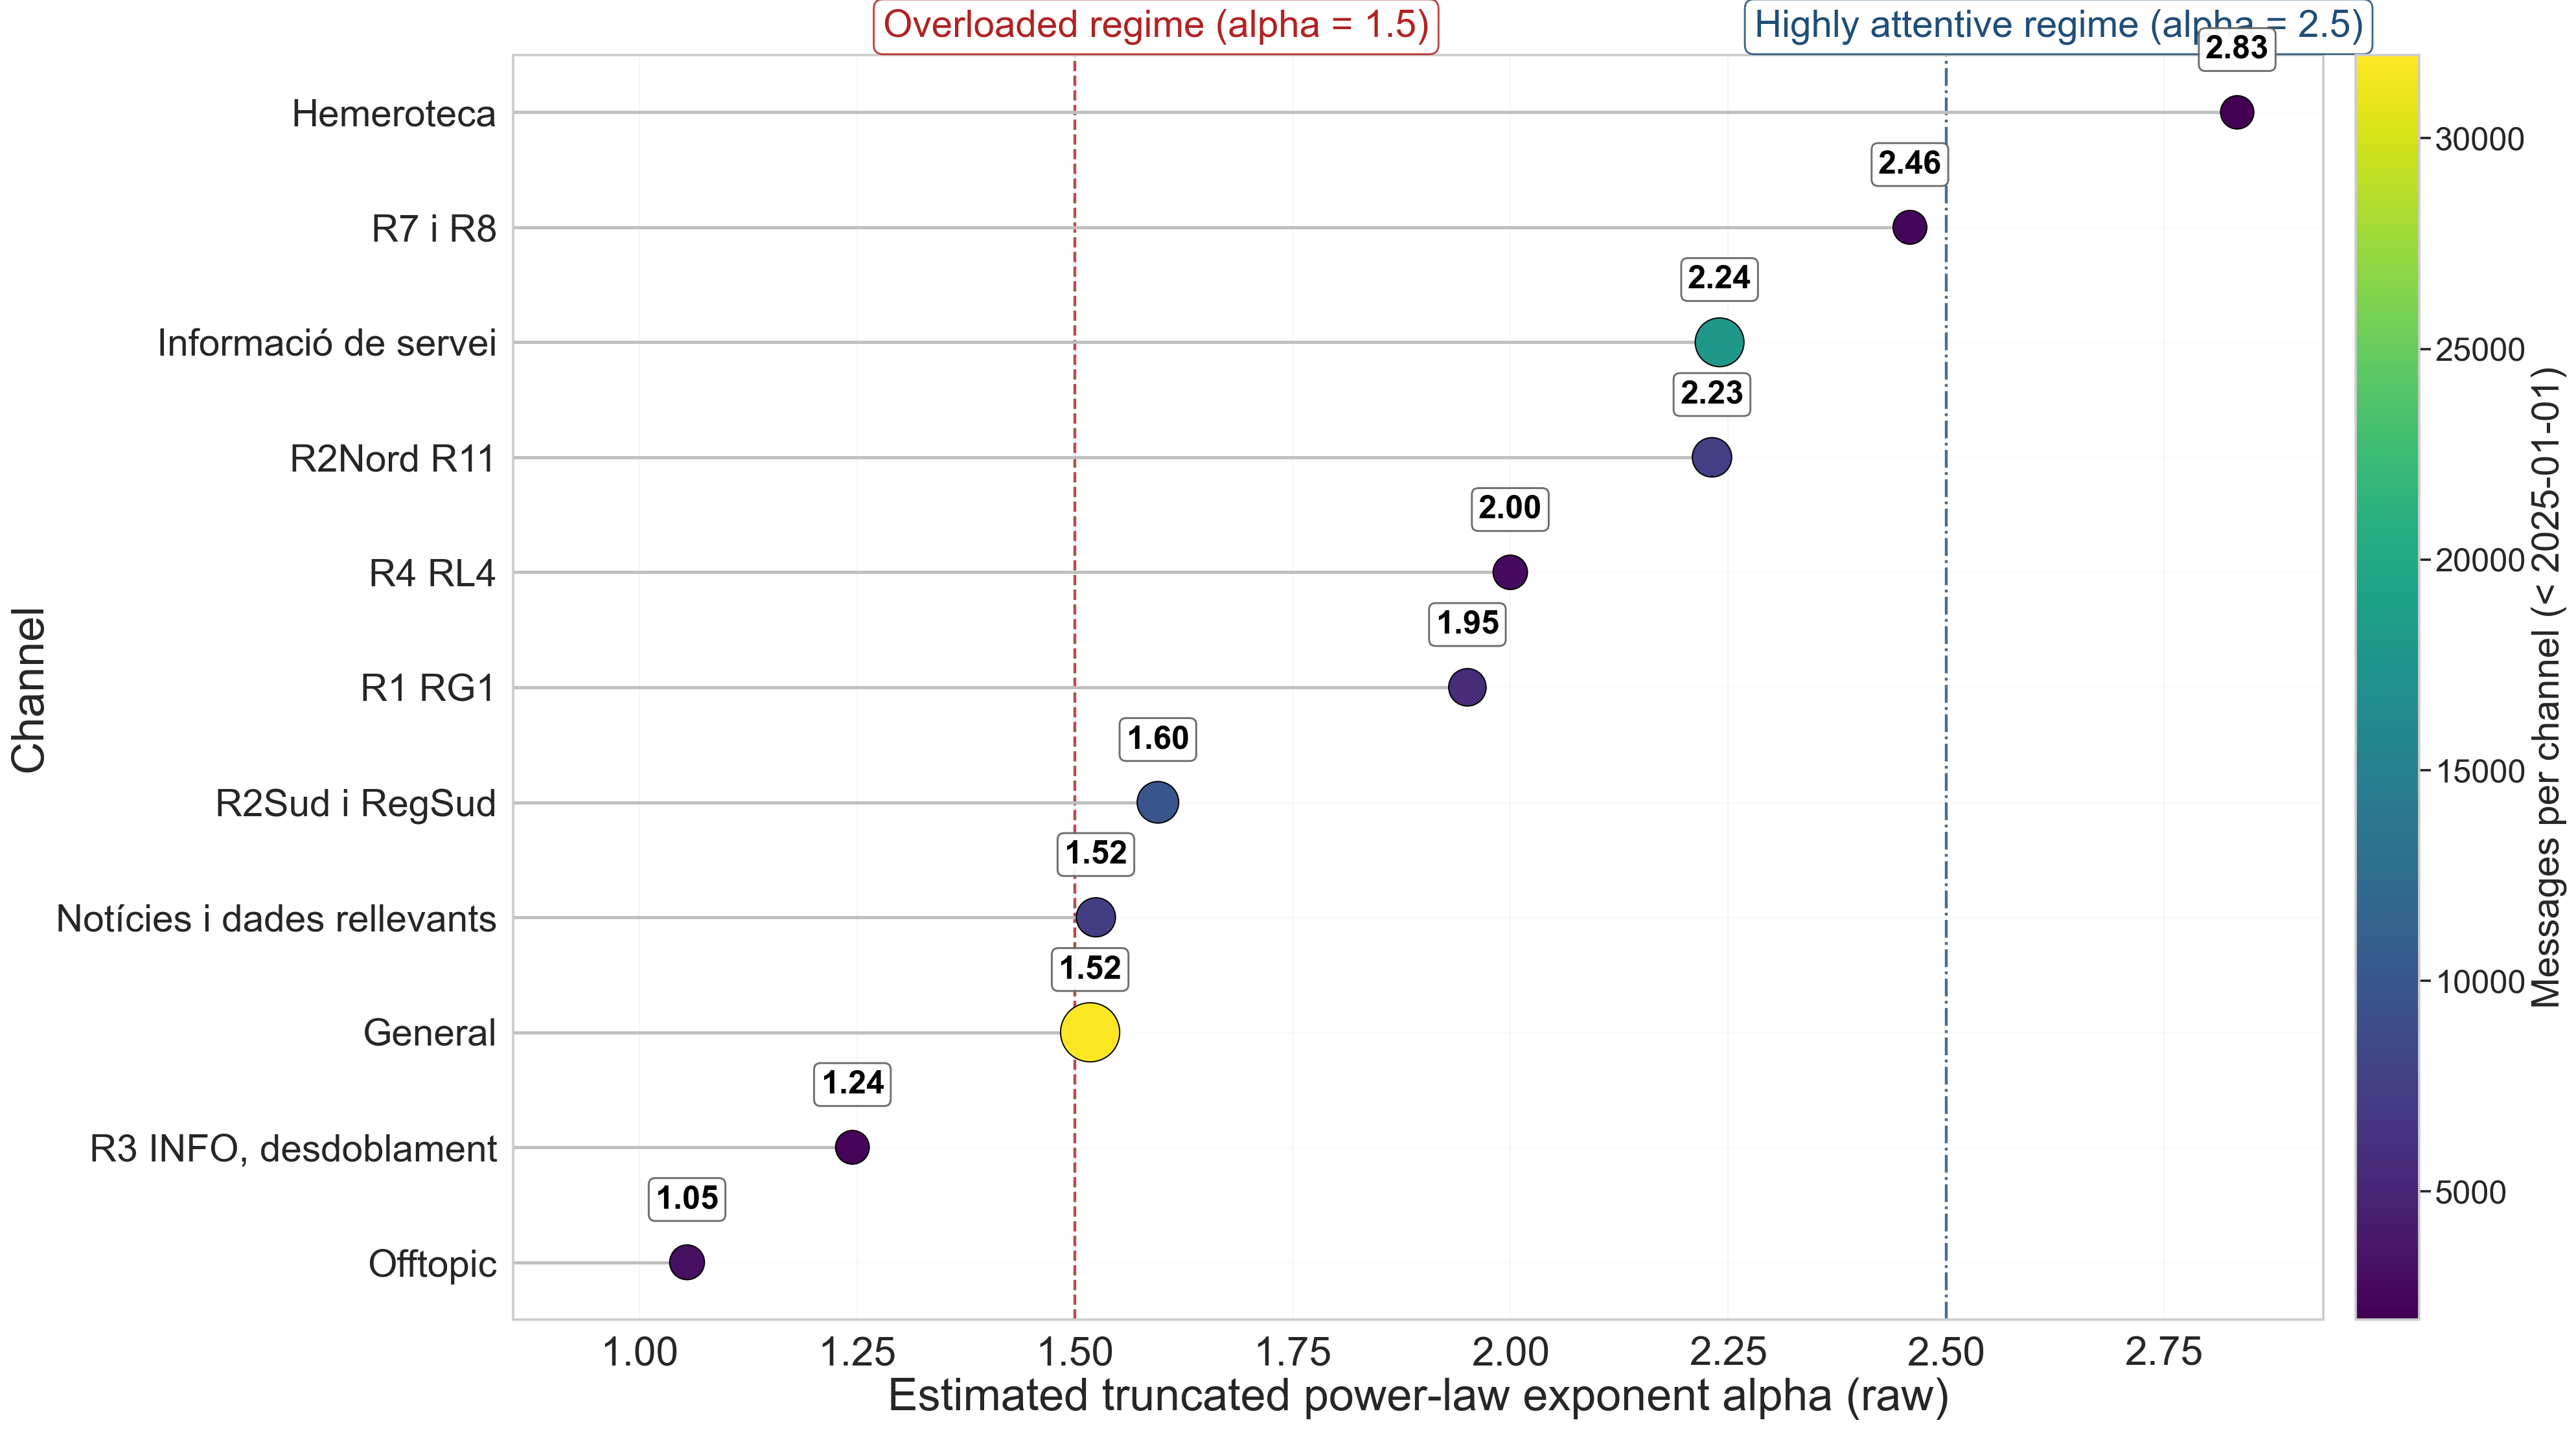

,channel,alpha_tpl,alpha_tpl_km,lambda_tpl_km,bias_sev,sigma_tpl,xmin,n_messages,n_waiting,n_tail
0,Offtopic,1.054821,1.759433,3.482264e-06,0.0102,NaN,125808.0,3176,3115,245
1,"R3 INFO, desdoblament",1.244622,1.596757,3.025651e-06,0.0147,NaN,54014.0,2287,2245,369
2,General,1.517537,2.310730,1.688709e-06,0.0112,NaN,54613.0,31982,6000,198
3,Notícies i dades rellevants,1.524168,1.829272,7.565855e-06,0.0062,NaN,59869.0,7282,6000,443
4,R2Sud i RegSud,1.595368,1.672766,1.466407e-05,0.0073,NaN,35167.0,9735,6000,326
5,R1 RG1,1.950652,2.476914,1.160271e-06,0.0089,NaN,46748.0,5624,5597,250
6,R4 RL4,1.999864,2.386492,6.161836e-06,0.0104,NaN,60843.0,2842,2811,201
7,R2Nord R11,2.231440,2.077253,2.514221e-06,0.0688,NaN,44505.0,7498,6000,261
8,Informació de servei,2.240163,2.200100,7.840673e-06,0.0059,NaN,37789.0,17957,6000,262
9,R7 i R8,2.458685,2.601082,5.997790e-07,0.0394,NaN,139566.0,2340,2333,81


<Figure size 896x672 with 0 Axes>

In [6]:
# TPL analysis: truncated power-law exponents across channels (>1000 msgs), up to 2025-01-01.
from scipy.optimize import curve_fit

results_tpl = []
for channel in eligible_channels:
    ch = df_alpha.loc[df_alpha['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]

    # KM correction (before subsampling)
    T_seconds = (cutoff_date - ch['date'].iloc[0]).total_seconds()
    tau_fc    = max((cutoff_date - ch['date'].iloc[-1]).total_seconds(), 0.0)
    bias_sev  = waiting.max() / T_seconds

    iet_vals = waiting.values
    km_dur   = np.concatenate([iet_vals, iet_vals, [tau_fc]])
    km_obs   = np.concatenate([np.ones(len(iet_vals)), np.ones(len(iet_vals)), [0]])
    kmf = KaplanMeierFitter()
    kmf.fit(km_dur, event_observed=km_obs.astype(bool))

    if len(waiting) < 100:
        continue
    if len(waiting) > 6000:
        waiting = waiting.sample(6000, random_state=42).sort_values()

    try:
        fit      = powerlaw.Fit(waiting.values, discrete=True, verbose=False)
        tpl      = fit.truncated_power_law
        alpha_tpl  = float(getattr(tpl, 'alpha', np.nan))
        sigma_tpl  = float(getattr(tpl, 'sigma', np.nan))
        xmin       = float(getattr(tpl, 'xmin', np.nan))
        n_tail     = int(np.sum(waiting.values >= xmin)) if np.isfinite(xmin) else np.nan

        # KM-corrected TPL via curve_fit on survival curve
        # Model: S(τ) = (τ/xmin)^{-(α-1)} · exp(-(τ-xmin)·Λ), normalized to 1 at xmin
        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask = (km_t >= xmin) & (km_s > 0) & (km_t > 0)

        alpha_tpl_km  = np.nan
        lambda_tpl_km = np.nan
        if np.isfinite(xmin) and mask.sum() > 5:
            km_t_tail = km_t[mask]
            km_s_norm = km_s[mask] / km_s[mask][0]

            def tpl_surv(t, alpha, lam):
                return (t / xmin) ** (-(alpha - 1)) * np.exp(-(t - xmin) * lam)

            try:
                popt, _ = curve_fit(
                    tpl_surv, km_t_tail, km_s_norm,
                    p0=[max(alpha_tpl, 1.01), 1.0 / iet_vals.max()],
                    bounds=([1.001, 0.0], [20.0, np.inf]),
                    maxfev=10000
                )
                alpha_tpl_km, lambda_tpl_km = float(popt[0]), float(popt[1])
            except Exception:
                pass

        if np.isfinite(alpha_tpl):
            results_tpl.append({
                'channel':       channel,
                'alpha_tpl':     alpha_tpl,
                'alpha_tpl_km':  alpha_tpl_km,
                'lambda_tpl_km': lambda_tpl_km,
                'bias_sev':      round(bias_sev, 4),
                'sigma_tpl':     sigma_tpl if np.isfinite(sigma_tpl) else np.nan,
                'xmin':          xmin,
                'n_messages':    int(channel_sizes[channel]),
                'n_waiting':     int(len(waiting)),
                'n_tail':        n_tail
            })
    except Exception as exc:
        print(f"Skipping channel: {channel} -> {exc}")

alpha_tpl_df = pd.DataFrame(results_tpl).sort_values('alpha_tpl', ascending=True).reset_index(drop=True)

if alpha_tpl_df.empty:
    raise ValueError('No valid TPL estimates could be computed.')

alpha_tpl_df['channel_label'] = alpha_tpl_df['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

# --- Poster: TPL raw ---
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'axes.titlesize': 42, 'axes.labelsize': 36,
    'xtick.labelsize': 32, 'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_tpl_df['alpha_tpl'].min() - 0.2)
for i, row in alpha_tpl_df.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_tpl'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(alpha_tpl_df['n_messages'],
                  (alpha_tpl_df['n_messages'].min(), alpha_tpl_df['n_messages'].max()), (700, 2200))
scatter = ax.scatter(alpha_tpl_df['alpha_tpl'], np.arange(len(alpha_tpl_df)),
                     s=sizes, c=alpha_tpl_df['n_messages'], cmap='viridis',
                     edgecolor='black', linewidth=1.0, zorder=3)

valid_sigma = alpha_tpl_df['sigma_tpl'].notna()
ax.errorbar(alpha_tpl_df.loc[valid_sigma, 'alpha_tpl'], np.where(valid_sigma)[0],
            xerr=alpha_tpl_df.loc[valid_sigma, 'sigma_tpl'],
            fmt='none', ecolor='0.25', elinewidth=1.5, capsize=5, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_tpl_df) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25'))
ax.text(2.28, len(alpha_tpl_df) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25'))

ax.set_yticks(np.arange(len(alpha_tpl_df)))
ax.set_yticklabels(alpha_tpl_df['channel_label'], fontsize=30)
ax.set_xlabel('Estimated truncated power-law exponent alpha (raw)', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (< 2025-01-01)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_tpl_df.iterrows():
    ax.annotate(f"{row['alpha_tpl']:.2f}", (row['alpha_tpl'], i),
                xytext=(0, 38), textcoords='offset points',
                va='bottom', ha='center', fontsize=26, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.savefig('alpha_tpl_poster.svg', format='svg', bbox_inches='tight')

alpha_tpl_df[['channel', 'alpha_tpl', 'alpha_tpl_km', 'lambda_tpl_km', 'bias_sev', 'sigma_tpl', 'xmin', 'n_messages', 'n_waiting', 'n_tail']]

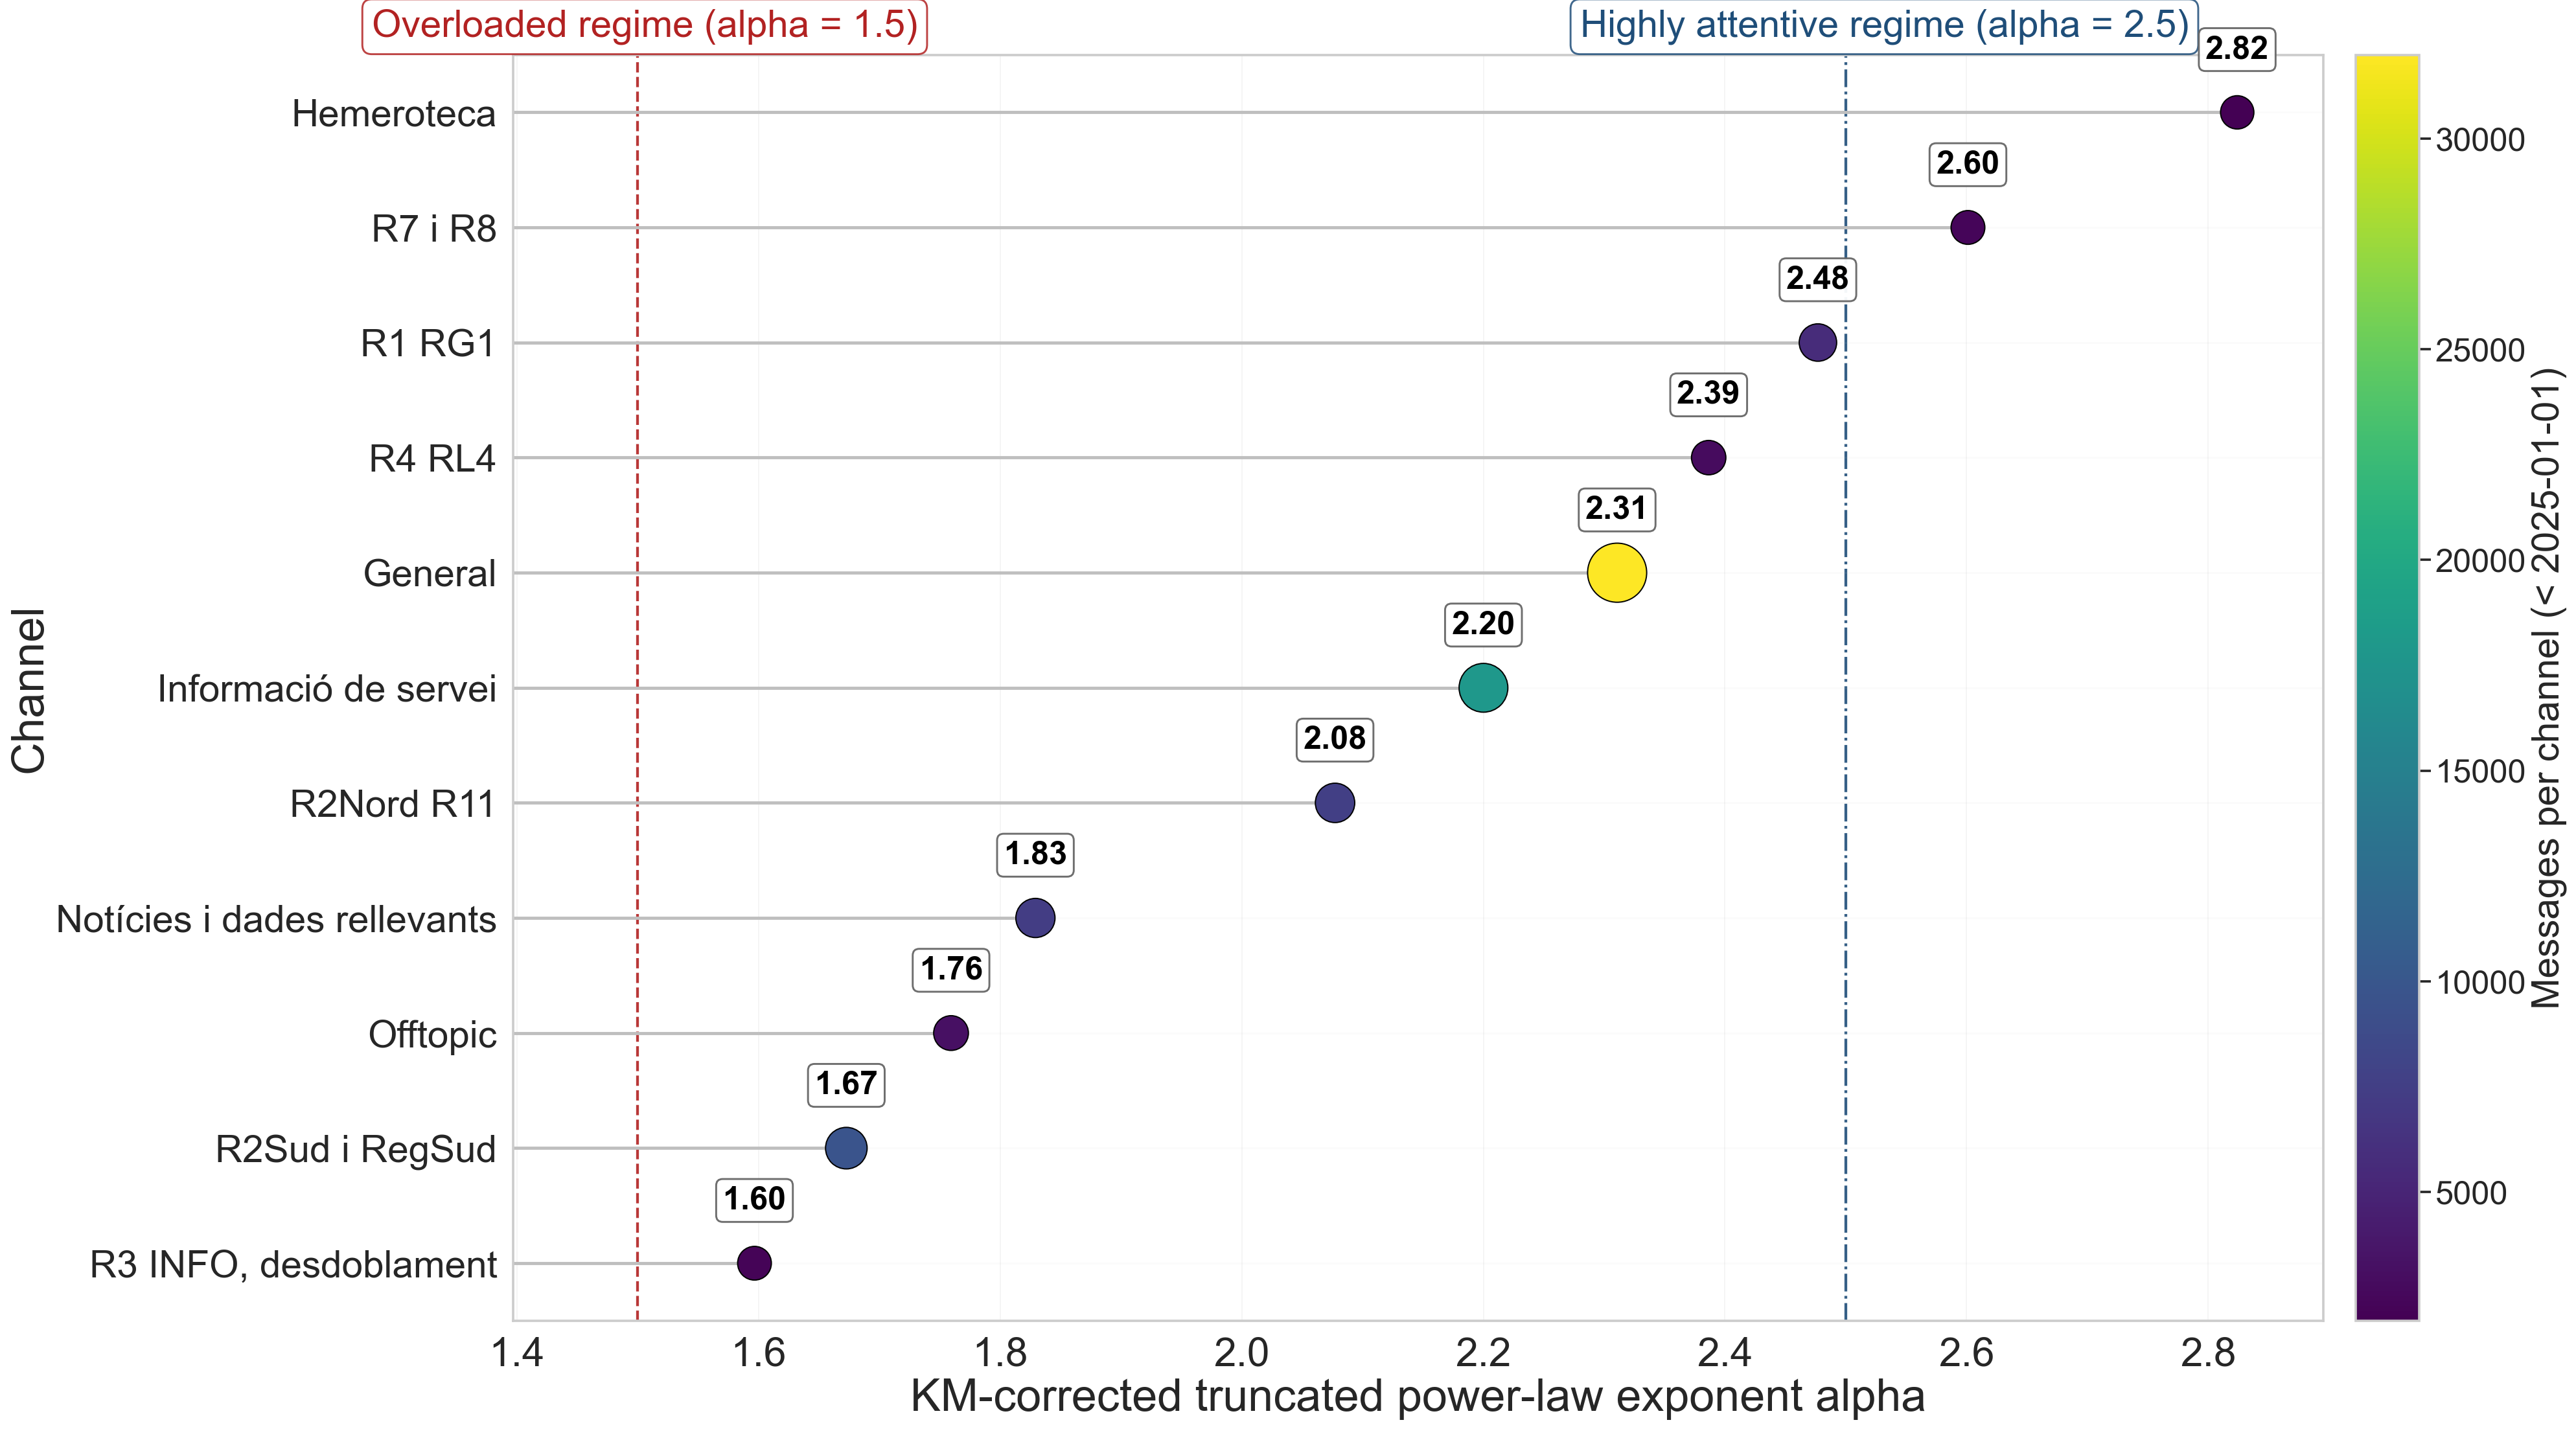

<Figure size 896x672 with 0 Axes>

In [7]:
# Poster: KM-corrected truncated power-law alpha

alpha_km_poster = alpha_tpl_df.dropna(subset=['alpha_tpl_km']).sort_values('alpha_tpl_km', ascending=True).reset_index(drop=True)
alpha_km_poster['channel_label'] = alpha_km_poster['channel'].apply(
    lambda s: __import__('textwrap').shorten(str(s), width=46, placeholder='...')
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'axes.titlesize': 42, 'axes.labelsize': 36,
    'xtick.labelsize': 32, 'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_km_poster['alpha_tpl_km'].min() - 0.2)
for i, row in alpha_km_poster.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_tpl_km'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(alpha_km_poster['n_messages'],
                  (alpha_km_poster['n_messages'].min(), alpha_km_poster['n_messages'].max()), (700, 2200))
scatter = ax.scatter(alpha_km_poster['alpha_tpl_km'], np.arange(len(alpha_km_poster)),
                     s=sizes, c=alpha_km_poster['n_messages'], cmap='viridis',
                     edgecolor='black', linewidth=1.0, zorder=3)

valid_sigma = alpha_km_poster['sigma_tpl'].notna()
ax.errorbar(alpha_km_poster.loc[valid_sigma, 'alpha_tpl_km'], np.where(valid_sigma)[0],
            xerr=alpha_km_poster.loc[valid_sigma, 'sigma_tpl'],
            fmt='none', ecolor='0.25', elinewidth=1.5, capsize=5, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_km_poster) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25'))
ax.text(2.28, len(alpha_km_poster) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25'))

ax.set_yticks(np.arange(len(alpha_km_poster)))
ax.set_yticklabels(alpha_km_poster['channel_label'], fontsize=30)
ax.set_xlabel('KM-corrected truncated power-law exponent alpha', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (< 2025-01-01)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_km_poster.iterrows():
    ax.annotate(f"{row['alpha_tpl_km']:.2f}", (row['alpha_tpl_km'], i),
                xytext=(0, 38), textcoords='offset points',
                va='bottom', ha='center', fontsize=26, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.savefig('alpha_tpl_km_poster.svg', format='svg', bbox_inches='tight')

### Vaga renfe daily messages


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/dates.py:449: UserWarning: no explicit representation of timezones available for np.datetime64
  d = d.astype('datetime64[us]')


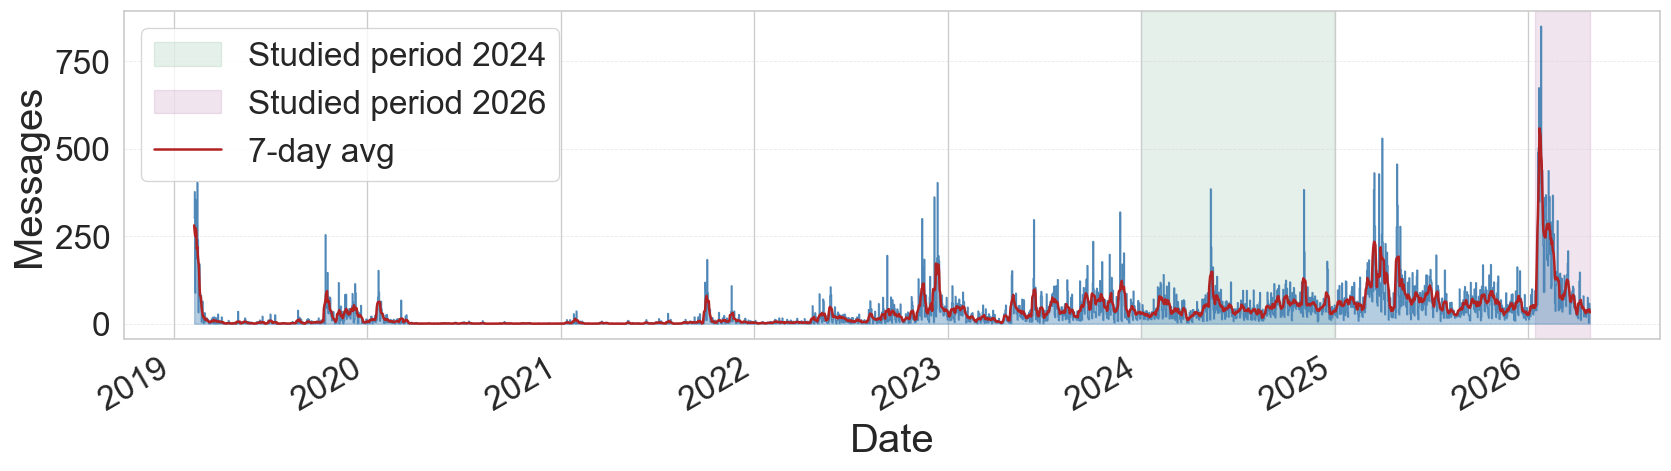

In [18]:
# daily message counts in the community (all channels combined)
df_daily = df.copy()
df_daily["date"] = pd.to_datetime(df_daily["date"], errors="coerce")
df_daily = df_daily.dropna(subset=["date"])
df_daily["day"] = df_daily["date"].dt.normalize()

daily_counts = df_daily.groupby("day").size().rename("n_messages")
# fill missing days with 0
daily_counts = daily_counts.reindex(
    pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq="D"), fill_value=0
)

with plt.rc_context({"axes.titlesize": 28, "axes.labelsize": 24,
                     "xtick.labelsize": 20, "ytick.labelsize": 20,
                     "legend.fontsize": 20, "figure.dpi": 120}):
    fig, ax = plt.subplots(figsize=(14, 4))

    # ── Studied region shading ────────────────────────────────────────────────
    region_2024_start = pd.Timestamp("2024-01-01")
    region_2024_end   = pd.Timestamp("2024-12-31")
    region_2026_start = pd.Timestamp("2026-01-15")
    region_2026_end   = daily_counts.index.max()

    ax.axvspan(region_2024_start, region_2024_end,
               color="#2E8B57", alpha=0.12, zorder=0, label="Studied period 2024")
    ax.axvspan(region_2026_start, region_2026_end,
               color="#8B2E7A", alpha=0.12, zorder=0, label="Studied period 2026")

    ax.fill_between(daily_counts.index, daily_counts.values, step="mid",
                    color="steelblue", alpha=0.4)
    ax.step(daily_counts.index, daily_counts.values, where="mid",
            color="steelblue", lw=0.8, alpha=0.9)

    # 7-day rolling average
    rolling = daily_counts.rolling(7, center=True, min_periods=1).mean()
    ax.plot(rolling.index, rolling.values, color="#B22222", lw=1.5, label="7-day avg")

    ax.set_xlabel("Date")
    ax.set_ylabel("Messages")
    ax.legend(loc='upper left')
    ax.grid(axis="y", ls="--", lw=0.5, alpha=0.4)
    fig.autofmt_xdate()
    plt.tight_layout()
    fig.savefig("daily_message_counts.pdf", format="pdf", bbox_inches="tight")
    plt.show()


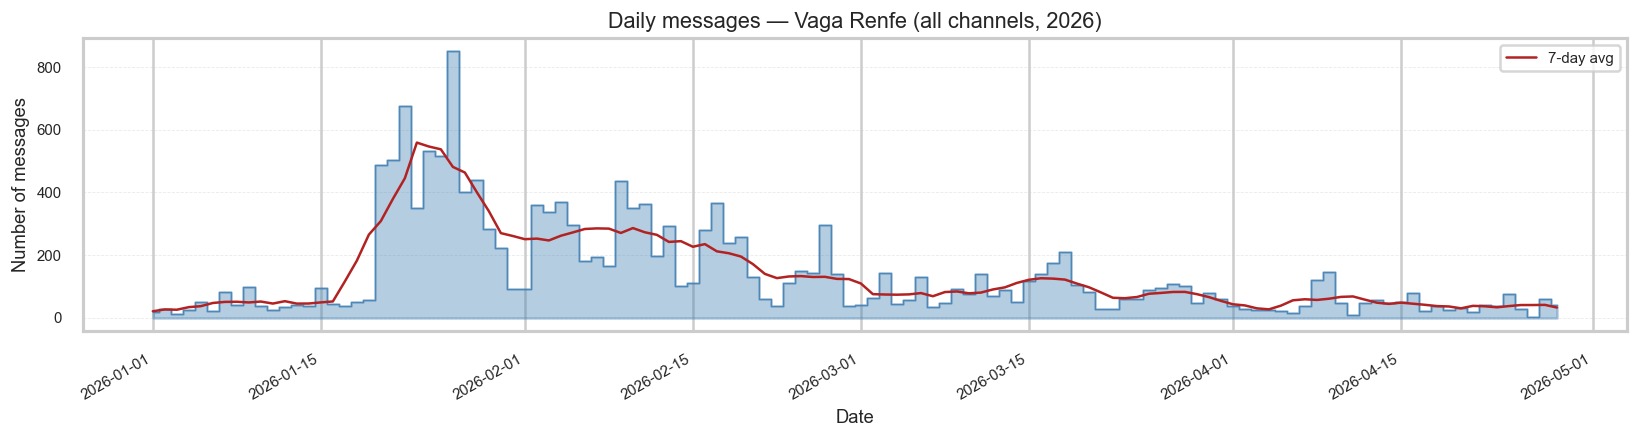

In [9]:

# daily message counts — 2026 only
daily_2026 = daily_counts[daily_counts.index.year == 2026]

with plt.rc_context({'axes.titlesize': 13, 'axes.labelsize': 11,
                     'xtick.labelsize': 9, 'ytick.labelsize': 9, 'figure.dpi': 120}):
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.fill_between(daily_2026.index, daily_2026.values, step='mid',
                    color='steelblue', alpha=0.4)
    ax.step(daily_2026.index, daily_2026.values, where='mid',
            color='steelblue', lw=0.8, alpha=0.9)

    rolling_2026 = daily_2026.rolling(7, center=True, min_periods=1).mean()
    ax.plot(rolling_2026.index, rolling_2026.values, color='#B22222', lw=1.5, label='7-day avg')

    ax.set_title('Daily messages — Vaga Renfe (all channels, 2026)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of messages')
    ax.legend(fontsize=9)
    ax.grid(axis='y', ls='--', lw=0.5, alpha=0.4)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


## Analysis with normal behavior

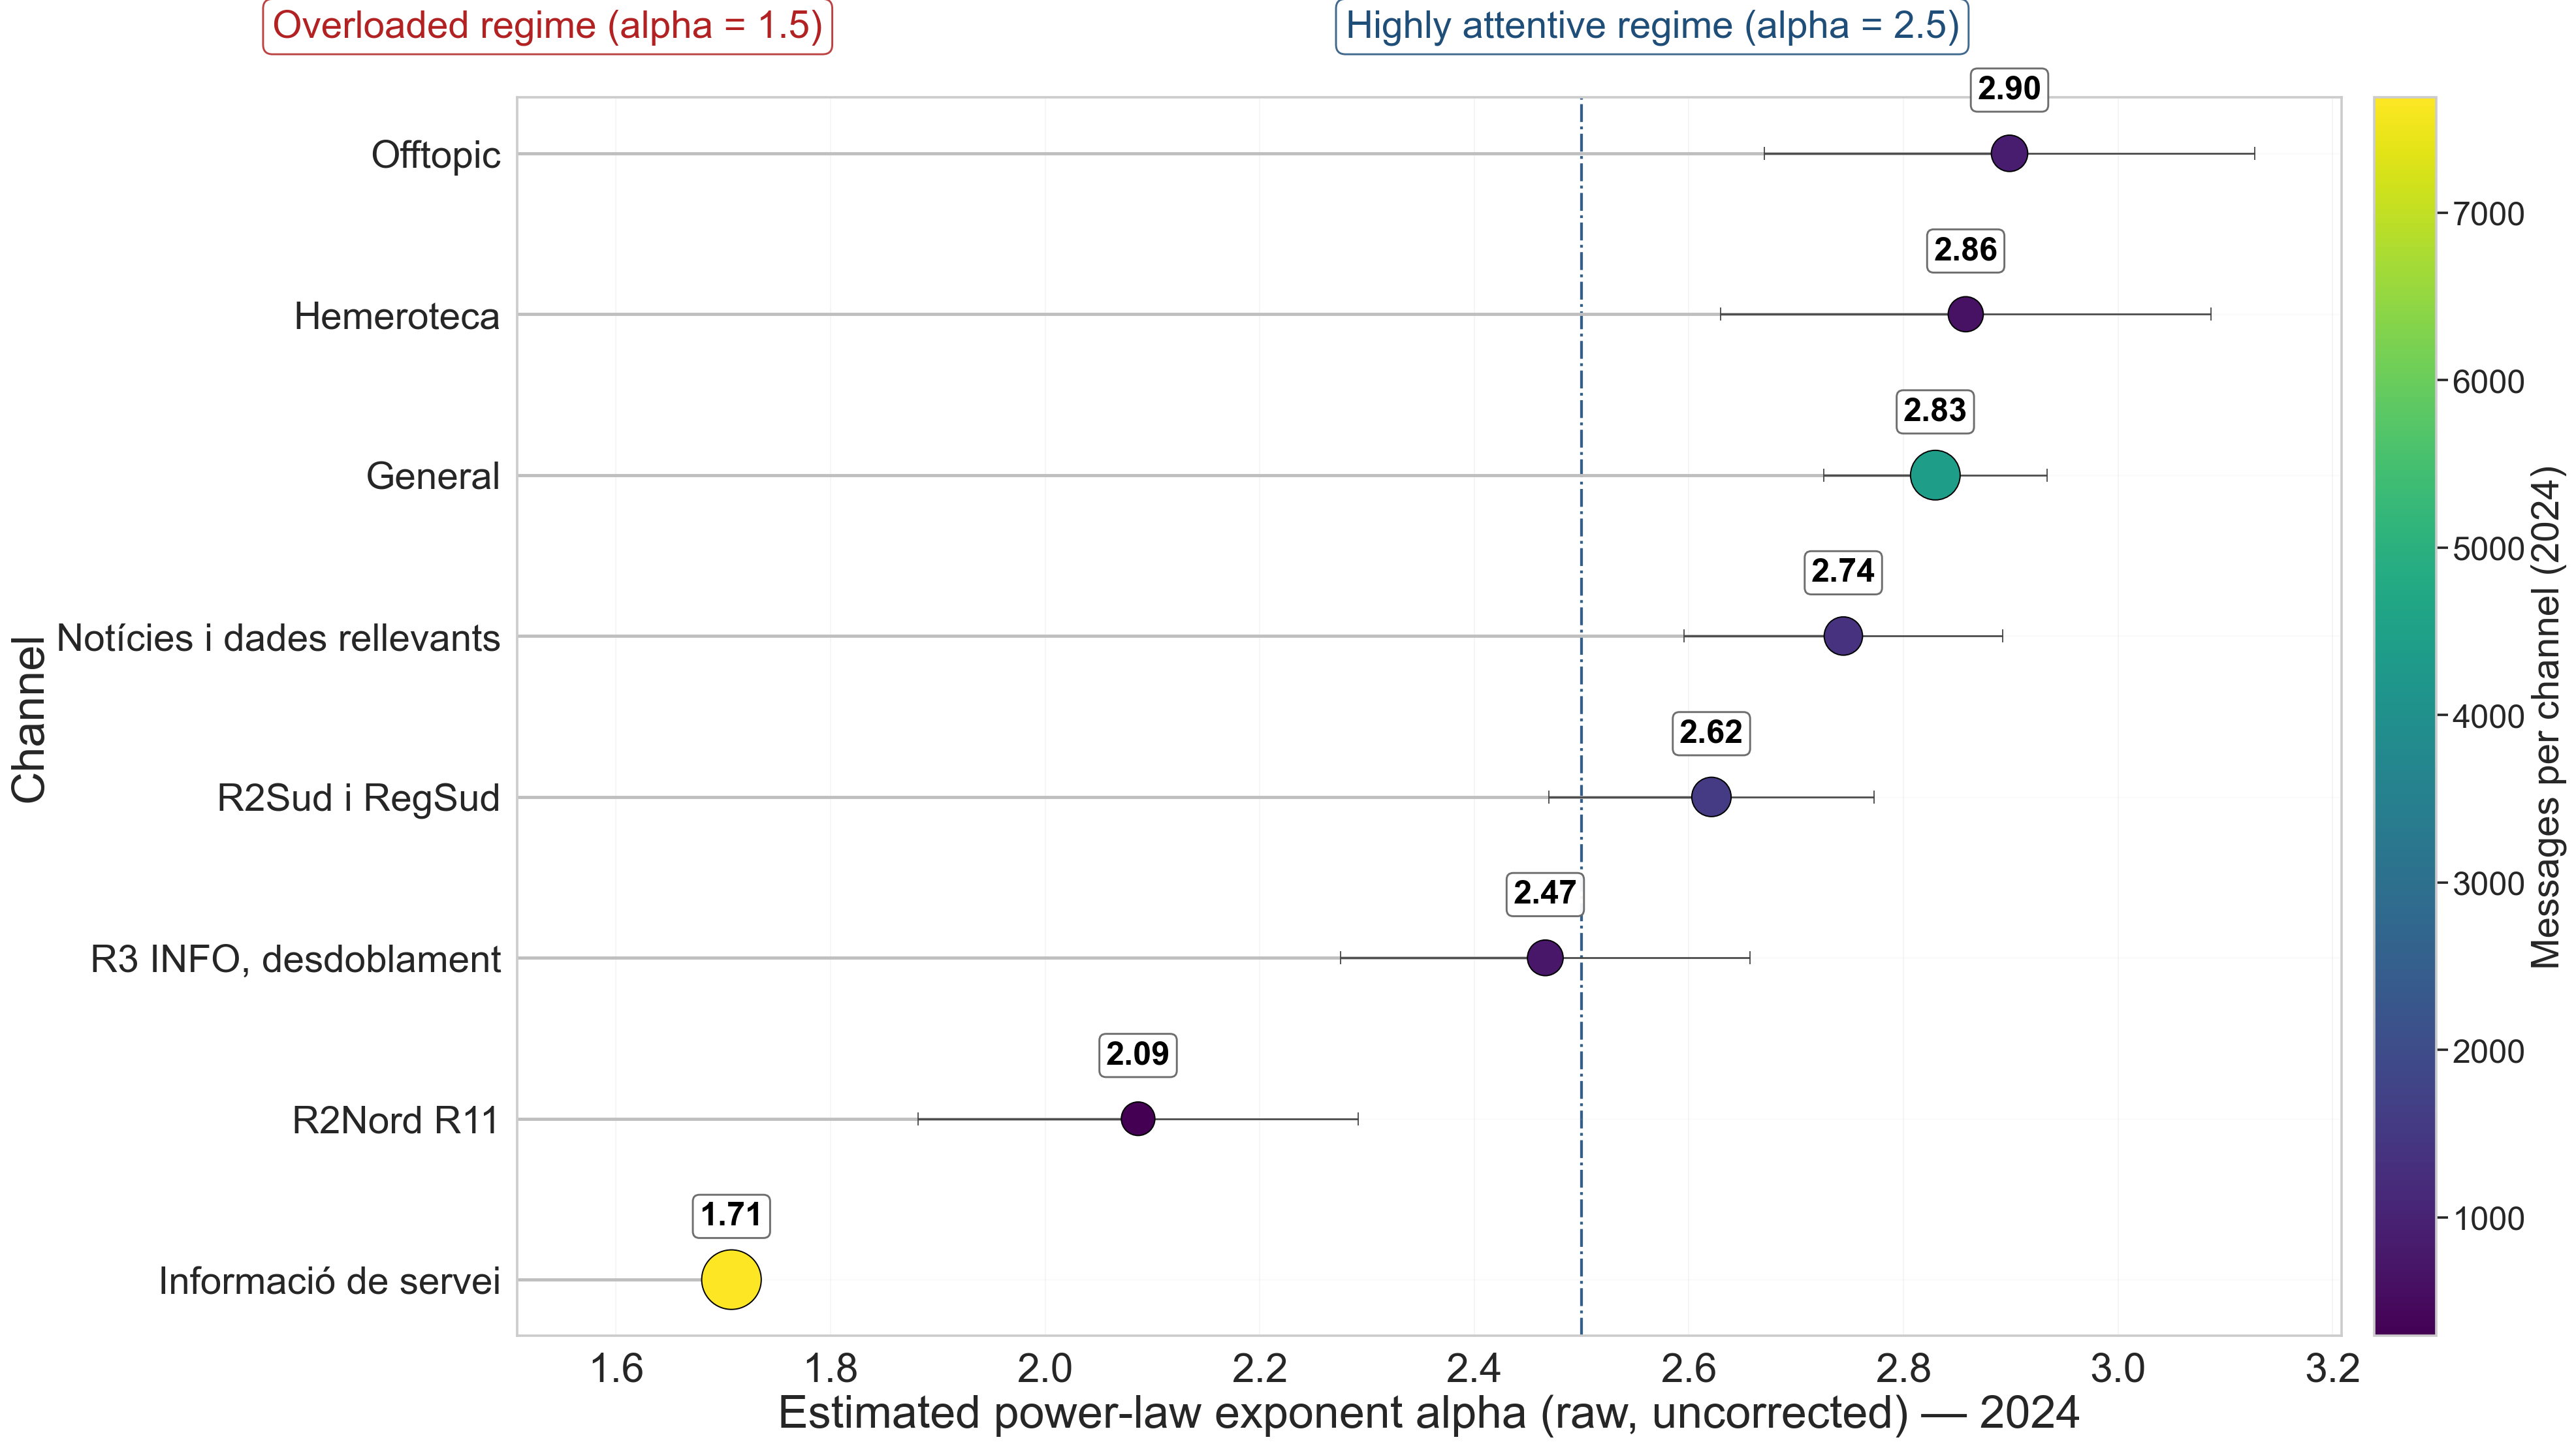

,channel,alpha,alpha_km,bias_sev,sigma,xmin,n_messages,n_waiting,n_tail
0,Informació de servei,1.707672,1.905320,0.0074,0.017975,2010.0,7690,6000,1550
1,R2Nord R11,2.086677,2.090188,0.1672,0.205363,225341.0,292,285,28
2,"R3 INFO, desdoblament",2.466199,2.594376,0.0379,0.190883,164764.0,747,736,59
3,R2Sud i RegSud,2.621055,2.854534,0.0238,0.151826,48690.0,1585,1554,114
4,Notícies i dades rellevants,2.744007,3.030464,0.0204,0.148460,71995.0,1347,1336,138
5,General,2.829730,3.306659,0.0085,0.104259,33060.0,4379,4289,308
6,Hemeroteca,2.858071,2.885251,0.0648,0.228713,145746.0,616,557,66
7,Offtopic,2.898880,3.289354,0.0274,0.228598,138313.0,896,872,69


<Figure size 896x672 with 0 Axes>

In [10]:
# PL analysis — Normal behavior (2024-01-01 to 2024-12-31)
df_nb = df.copy()
df_nb['date'] = pd.to_datetime(df_nb['date'], errors='coerce')
df_nb = df_nb.dropna(subset=['date', 'topic_name'])
df_nb = df_nb[df_nb['date'].dt.year == 2024]
cutoff_nb = df_nb['date'].max()

channel_sizes_nb = df_nb.groupby('topic_name').size().sort_values(ascending=False)
eligible_nb = channel_sizes_nb[channel_sizes_nb > 100].index

results_nb = []
for channel in eligible_nb:
    ch = df_nb.loc[df_nb['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]

    T_seconds = (cutoff_nb - ch['date'].iloc[0]).total_seconds()
    tau_fc    = max((cutoff_nb - ch['date'].iloc[-1]).total_seconds(), 0.0)
    bias_sev  = waiting.max() / T_seconds

    iet_vals = waiting.values
    km_dur   = np.concatenate([iet_vals, iet_vals, [tau_fc]])
    km_obs   = np.concatenate([np.ones(len(iet_vals)), np.ones(len(iet_vals)), [0]])
    kmf = KaplanMeierFitter()
    kmf.fit(km_dur, event_observed=km_obs.astype(bool))

    if len(waiting) < 50:
        continue
    if len(waiting) > 6000:
        waiting = waiting.sample(6000, random_state=42).sort_values()

    try:
        fit   = powerlaw.Fit(waiting.values, discrete=True, verbose=False)
        pl    = fit.power_law
        alpha = float(getattr(pl, 'alpha', np.nan))
        sigma = float(getattr(pl, 'sigma', np.nan))
        xmin  = float(getattr(pl, 'xmin', np.nan))
        n_tail = int(np.sum(waiting.values >= xmin)) if np.isfinite(xmin) else np.nan

        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask = (km_t >= xmin) & (km_s > 0) & (km_t > 0)
        if np.isfinite(xmin) and mask.sum() > 5:
            slope, _ = np.polyfit(np.log(km_t[mask]), np.log(km_s[mask]), 1)
            alpha_km = float(1.0 - slope)
        else:
            alpha_km = np.nan

        if np.isfinite(alpha):
            results_nb.append({
                'channel':    channel,
                'alpha':      alpha,
                'alpha_km':   alpha_km,
                'bias_sev':   round(bias_sev, 4),
                'sigma':      sigma if np.isfinite(sigma) else np.nan,
                'xmin':       xmin,
                'n_messages': int(channel_sizes_nb[channel]),
                'n_waiting':  int(len(waiting)),
                'n_tail':     n_tail
            })
    except Exception as exc:
        print(f"Skipping {channel}: {exc}")

alpha_df_nb = pd.DataFrame(results_nb).sort_values('alpha', ascending=True).reset_index(drop=True)
alpha_df_nb['channel_label'] = alpha_df_nb['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

# PL raw lollipop
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'axes.titlesize': 42, 'axes.labelsize': 36,
    'xtick.labelsize': 32, 'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_df_nb['alpha'].min() - 0.2)
for i, row in alpha_df_nb.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(alpha_df_nb['n_messages'],
                  (alpha_df_nb['n_messages'].min(), alpha_df_nb['n_messages'].max()), (700, 2200))
scatter = ax.scatter(alpha_df_nb['alpha'], np.arange(len(alpha_df_nb)),
                     s=sizes, c=alpha_df_nb['n_messages'], cmap='viridis',
                     edgecolor='black', linewidth=1.0, zorder=3)

valid_sigma = alpha_df_nb['sigma'].notna()
ax.errorbar(alpha_df_nb.loc[valid_sigma, 'alpha'], np.where(valid_sigma)[0],
            xerr=alpha_df_nb.loc[valid_sigma, 'sigma'],
            fmt='none', ecolor='0.25', elinewidth=1.5, capsize=5, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_df_nb) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25'))
ax.text(2.28, len(alpha_df_nb) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25'))

ax.set_yticks(np.arange(len(alpha_df_nb)))
ax.set_yticklabels(alpha_df_nb['channel_label'], fontsize=30)
ax.set_xlabel('Estimated power-law exponent alpha (raw, uncorrected) — 2024', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (2024)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_df_nb.iterrows():
    ax.annotate(f"{row['alpha']:.2f}", (row['alpha'], i),
                xytext=(0, 38), textcoords='offset points',
                va='bottom', ha='center', fontsize=26, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.savefig('alpha_pl_nb_poster.svg', format='svg', bbox_inches='tight')

alpha_df_nb[['channel', 'alpha', 'alpha_km', 'bias_sev', 'sigma', 'xmin', 'n_messages', 'n_waiting', 'n_tail']]

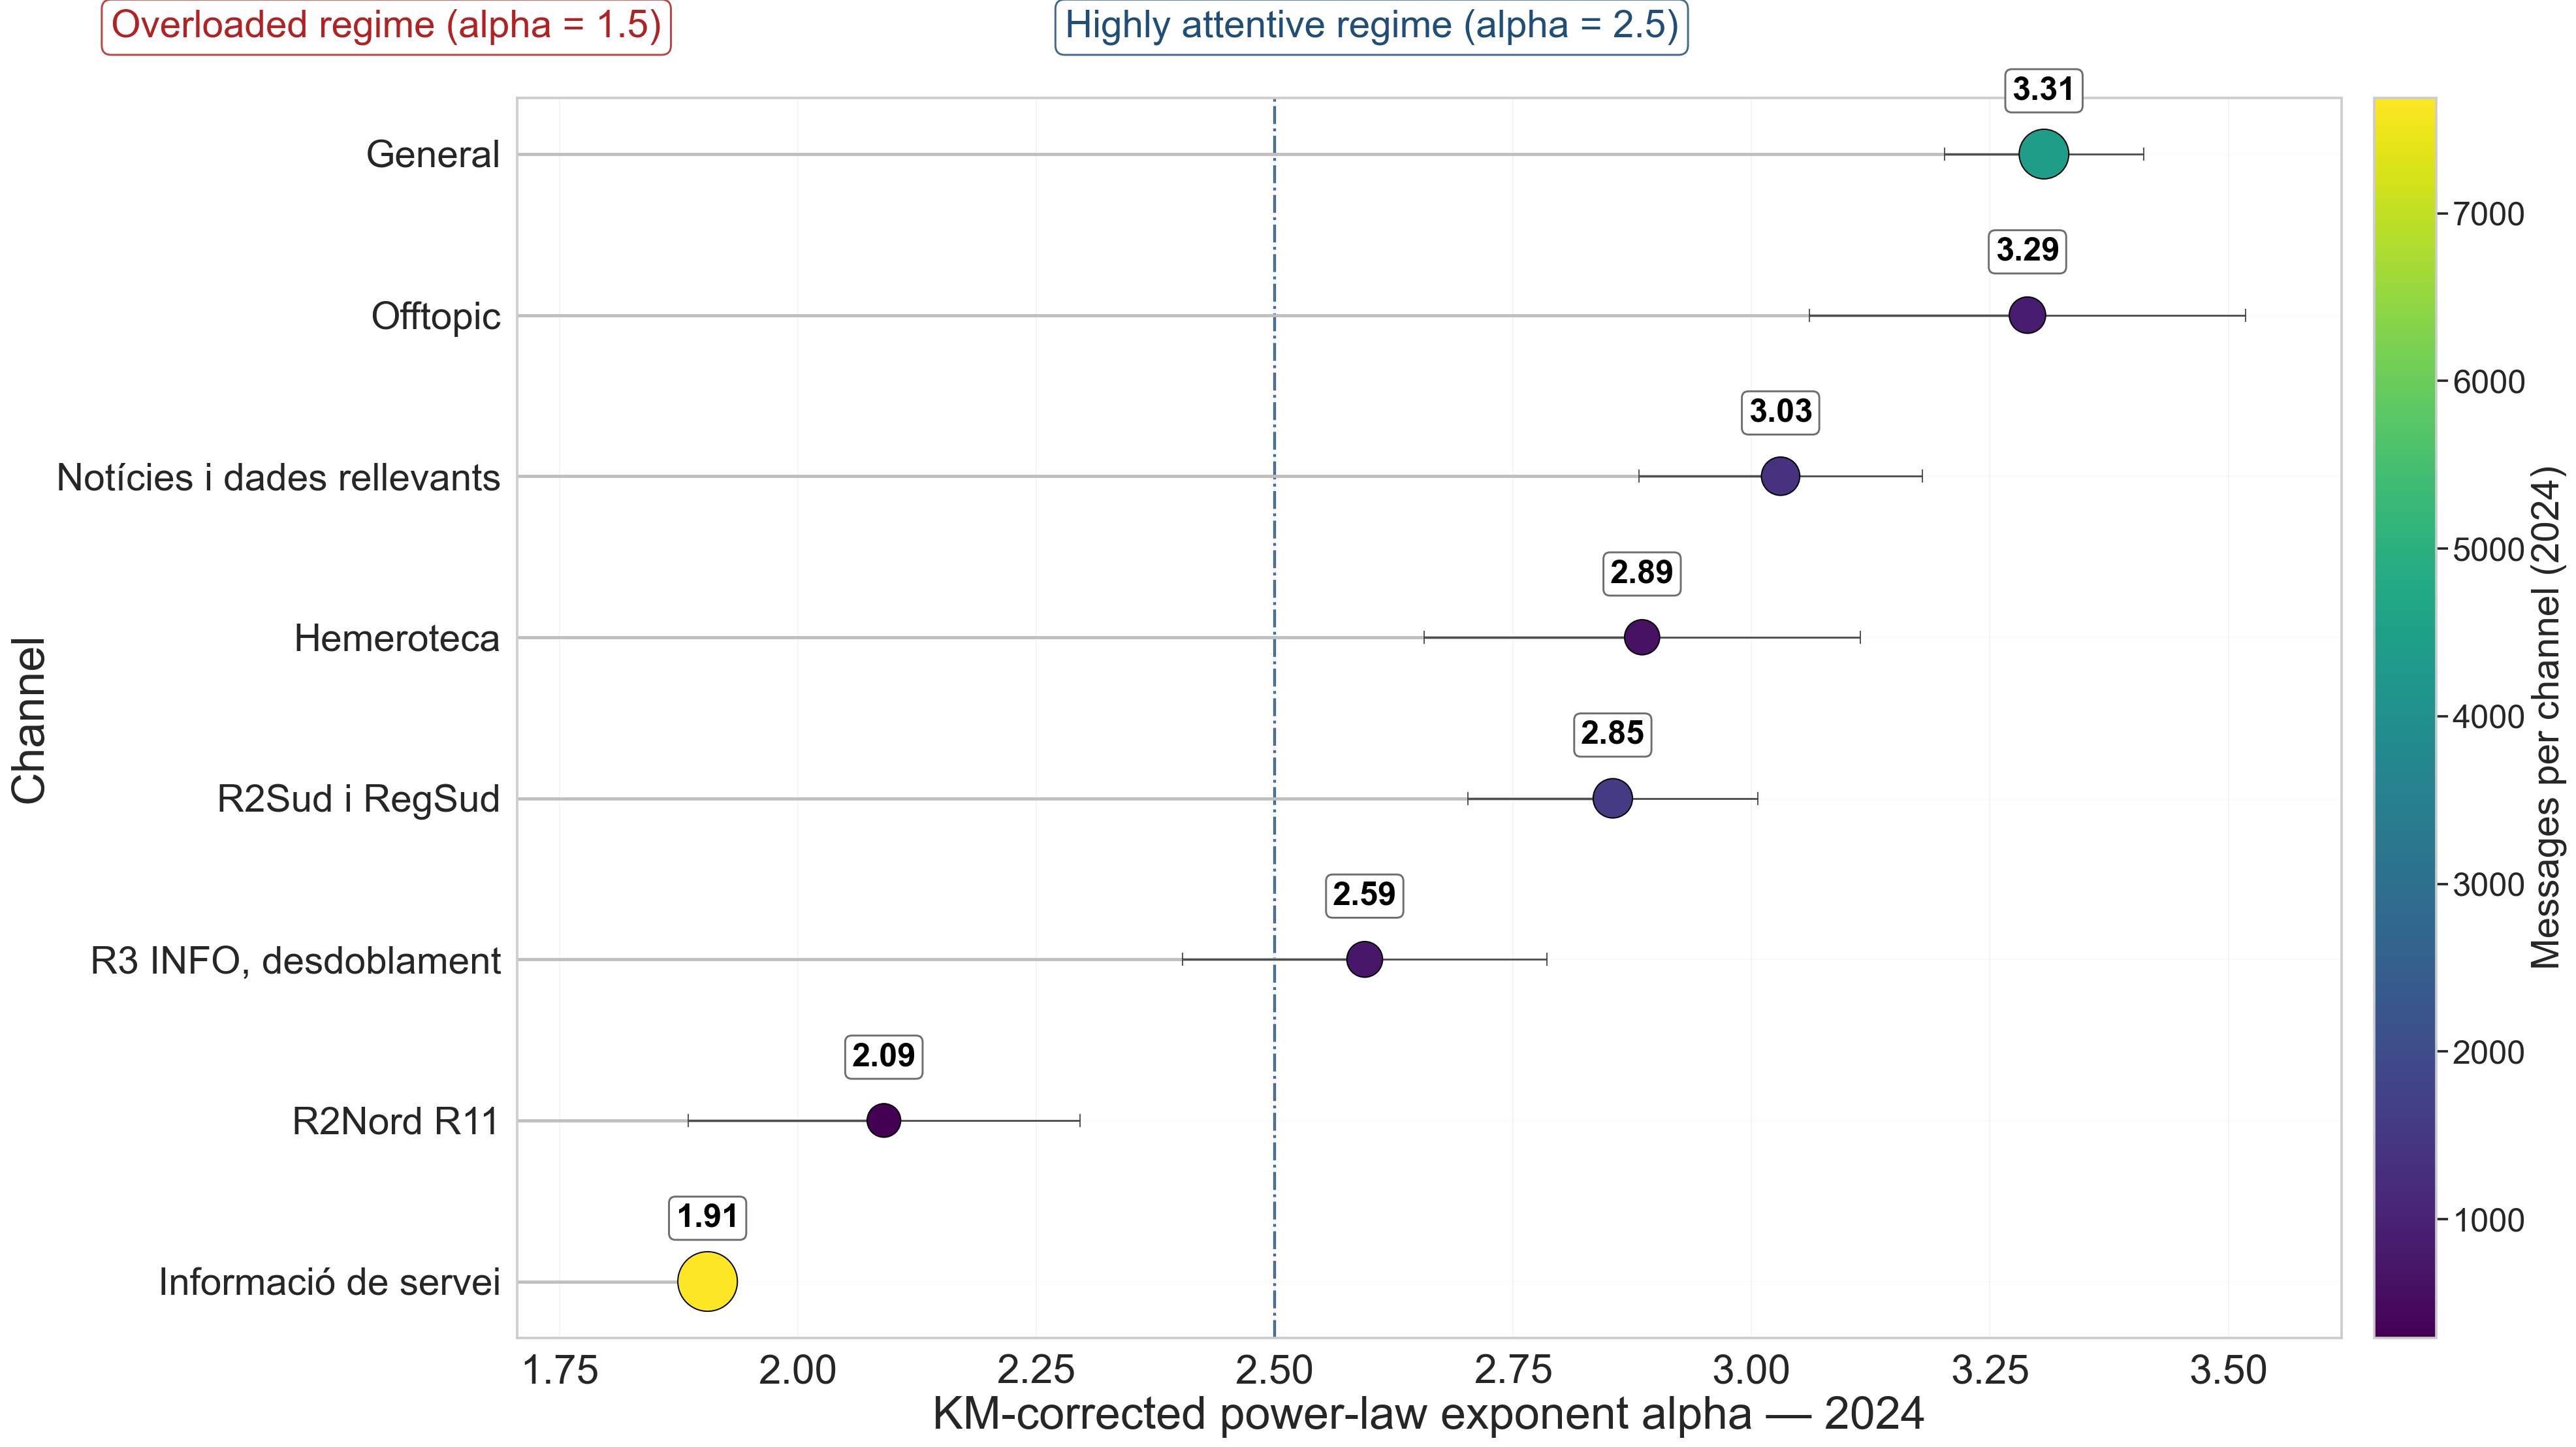

<Figure size 896x672 with 0 Axes>

In [11]:
# PL KM-corrected lollipop — Normal behavior (2024)
alpha_km_nb = alpha_df_nb.dropna(subset=['alpha_km']).sort_values('alpha_km', ascending=True).reset_index(drop=True)
alpha_km_nb['channel_label'] = alpha_km_nb['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'axes.titlesize': 42, 'axes.labelsize': 36,
    'xtick.labelsize': 32, 'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_km_nb['alpha_km'].min() - 0.2)
for i, row in alpha_km_nb.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_km'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(alpha_km_nb['n_messages'],
                  (alpha_km_nb['n_messages'].min(), alpha_km_nb['n_messages'].max()), (700, 2200))
scatter = ax.scatter(alpha_km_nb['alpha_km'], np.arange(len(alpha_km_nb)),
                     s=sizes, c=alpha_km_nb['n_messages'], cmap='viridis',
                     edgecolor='black', linewidth=1.0, zorder=3)

valid_sigma = alpha_km_nb['sigma'].notna()
ax.errorbar(alpha_km_nb.loc[valid_sigma, 'alpha_km'], np.where(valid_sigma)[0],
            xerr=alpha_km_nb.loc[valid_sigma, 'sigma'],
            fmt='none', ecolor='0.25', elinewidth=1.5, capsize=5, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_km_nb) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25'))
ax.text(2.28, len(alpha_km_nb) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25'))

ax.set_yticks(np.arange(len(alpha_km_nb)))
ax.set_yticklabels(alpha_km_nb['channel_label'], fontsize=30)
ax.set_xlabel('KM-corrected power-law exponent alpha — 2024', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (2024)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_km_nb.iterrows():
    ax.annotate(f"{row['alpha_km']:.2f}", (row['alpha_km'], i),
                xytext=(0, 38), textcoords='offset points',
                va='bottom', ha='center', fontsize=26, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.savefig('alpha_km_nb_poster.svg', format='svg', bbox_inches='tight')

### Truncated power law (normal behavior)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

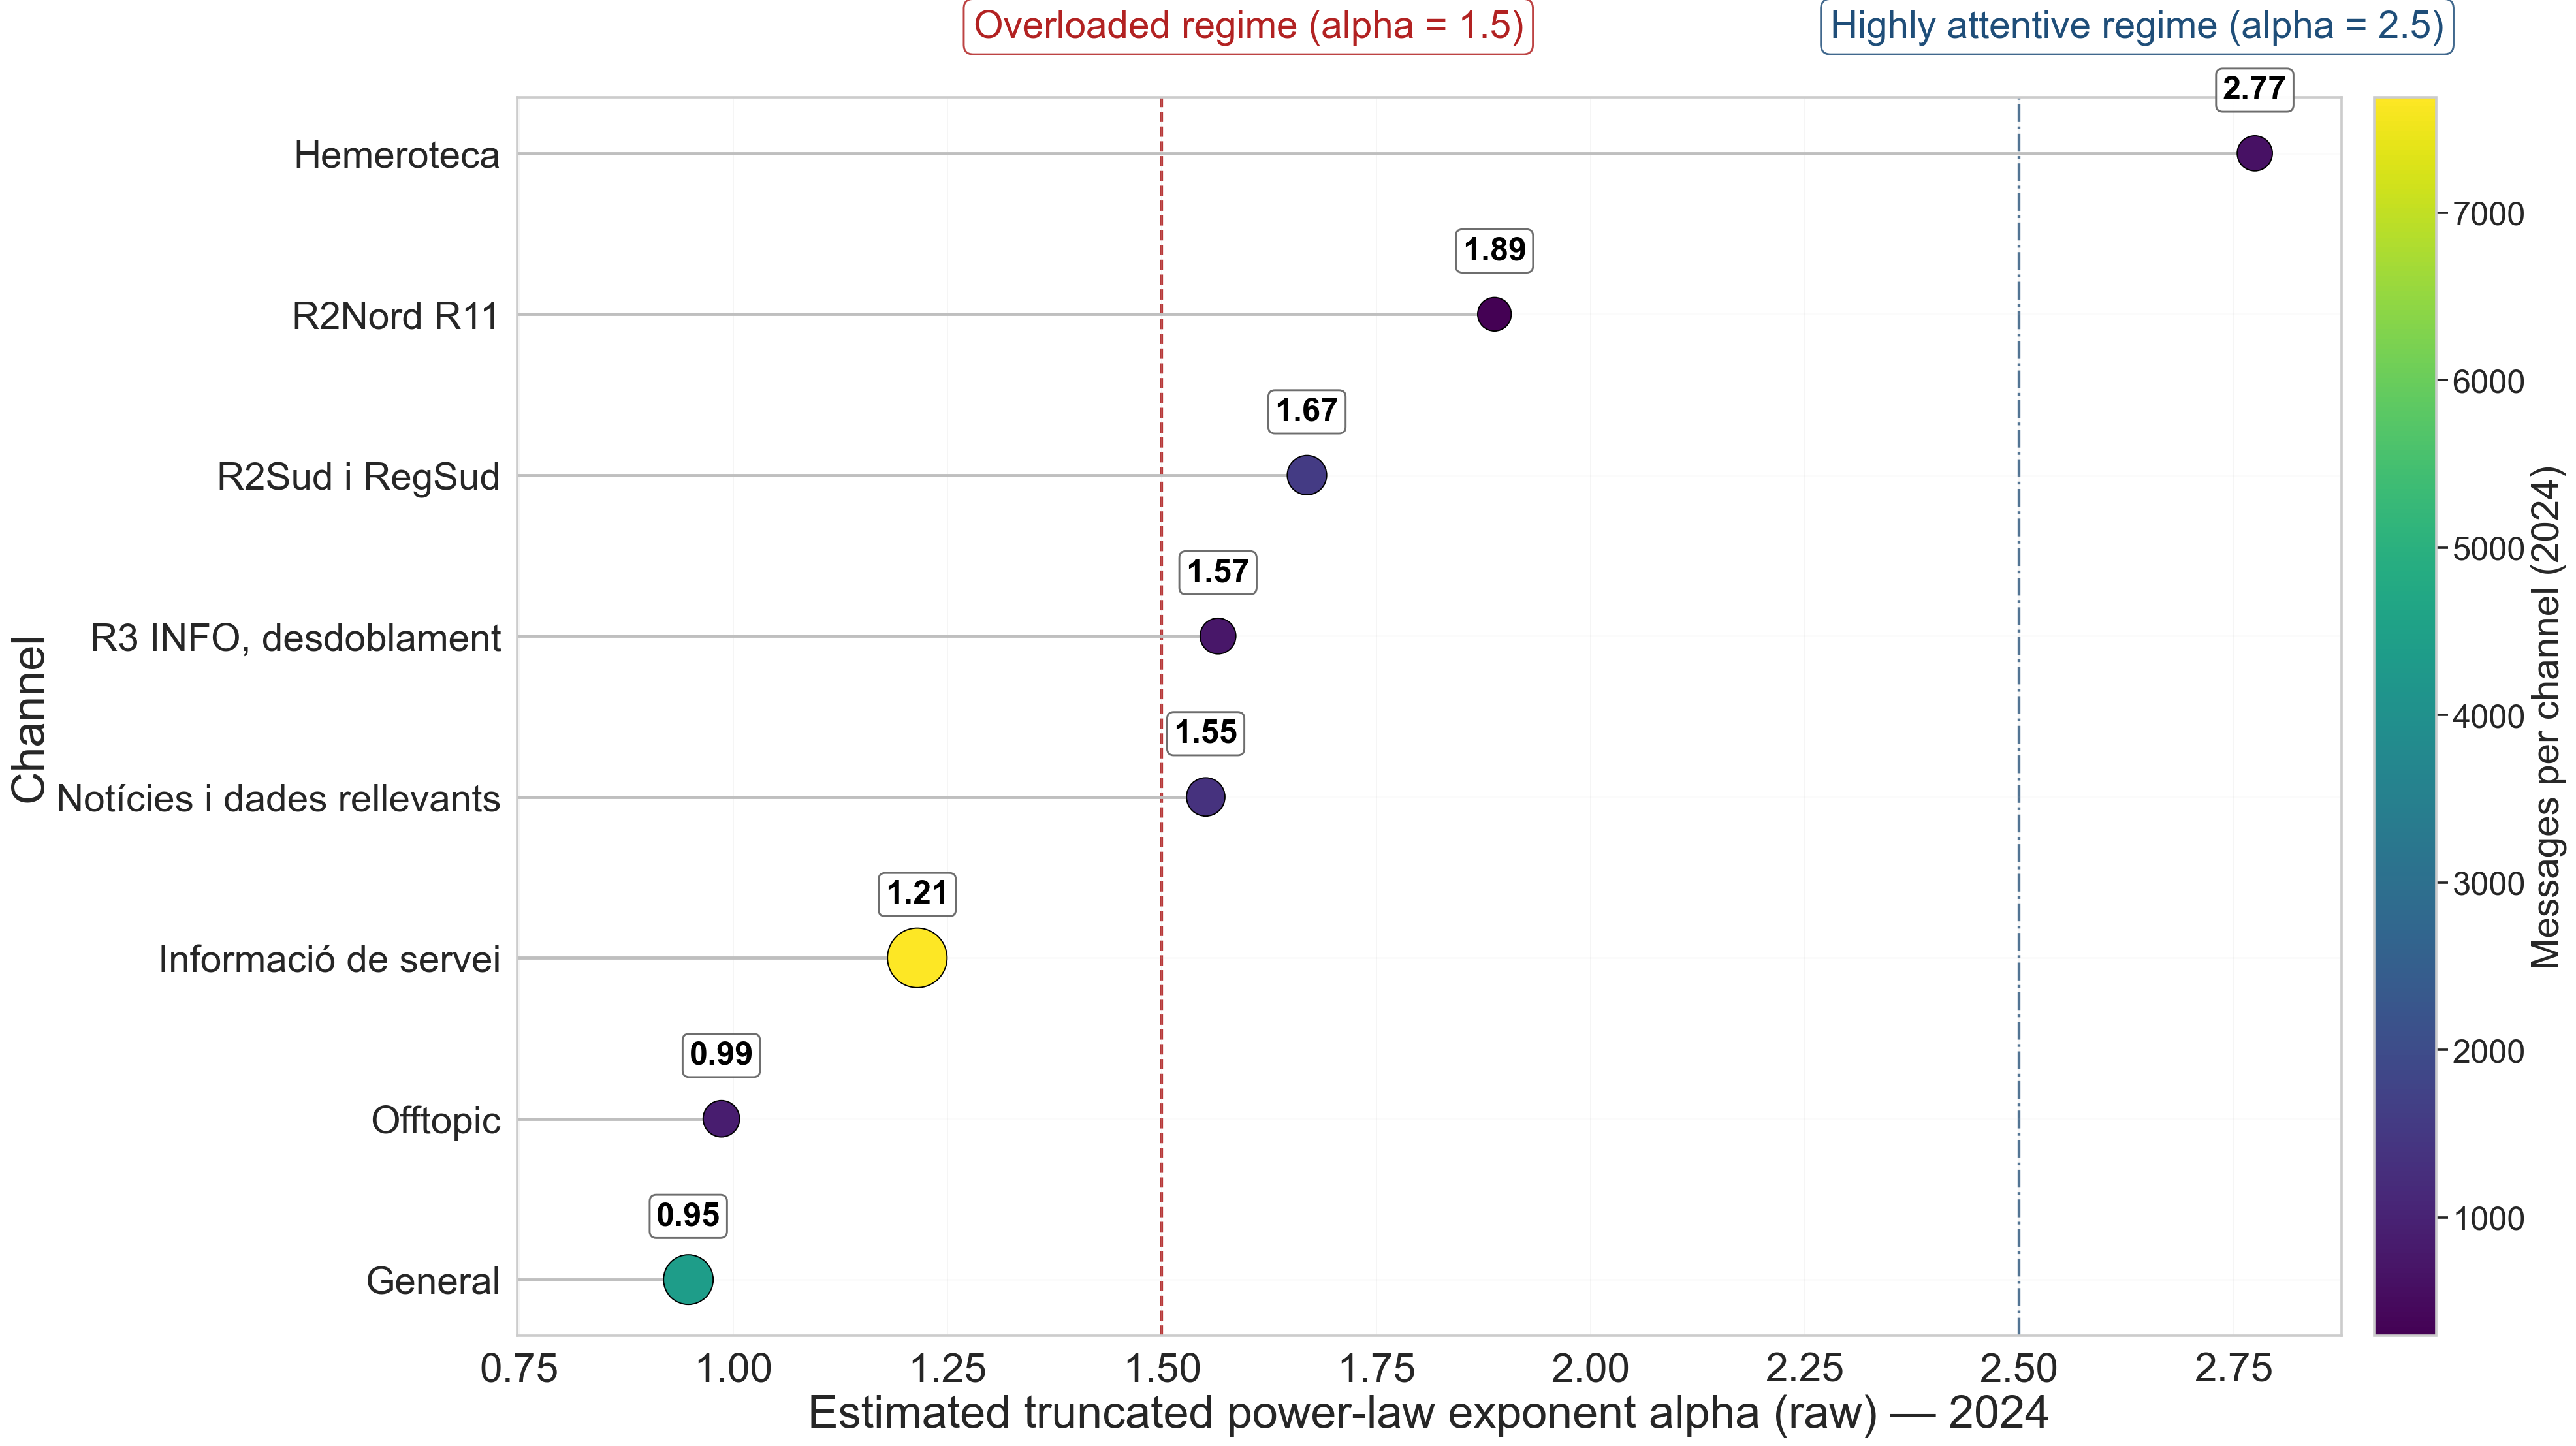

,channel,alpha_tpl,alpha_tpl_km,lambda_tpl_km,bias_sev,sigma_tpl,sigma_alpha_km,xmin,n_messages,n_waiting,n_tail
0,General,0.947581,1.214637,3.016564e-05,0.0085,NaN,0.027404,33060.0,4379,4289,308
1,Offtopic,0.986083,1.678251,5.306615e-06,0.0274,NaN,0.084683,138313.0,896,872,69
2,Informació de servei,1.214650,1.499398,1.974408e-05,0.0074,NaN,0.001024,2010.0,7690,6000,1550
3,Notícies i dades rellevants,1.551178,1.938884,5.962592e-06,0.0204,NaN,0.046609,71995.0,1347,1336,138
4,"R3 INFO, desdoblament",1.565476,2.173402,6.820331e-07,0.0379,NaN,0.075653,164764.0,747,736,59
5,R2Sud i RegSud,1.669254,2.183378,4.356142e-06,0.0238,NaN,0.036374,48690.0,1585,1554,114
6,R2Nord R11,1.888003,2.025757,9.097239e-08,0.1672,NaN,0.065316,225341.0,292,285,28
7,Hemeroteca,2.774997,2.878187,6.185026e-13,0.0648,NaN,0.088256,145746.0,616,557,66


<Figure size 896x672 with 0 Axes>

In [12]:
# TPL analysis — Normal behavior (2024)
from scipy.optimize import curve_fit

results_tpl_nb = []
for channel in eligible_nb:
    ch = df_nb.loc[df_nb['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]

    T_seconds = (cutoff_nb - ch['date'].iloc[0]).total_seconds()
    tau_fc    = max((cutoff_nb - ch['date'].iloc[-1]).total_seconds(), 0.0)
    bias_sev  = waiting.max() / T_seconds

    iet_vals = waiting.values
    km_dur   = np.concatenate([iet_vals, iet_vals, [tau_fc]])
    km_obs   = np.concatenate([np.ones(len(iet_vals)), np.ones(len(iet_vals)), [0]])
    kmf = KaplanMeierFitter()
    kmf.fit(km_dur, event_observed=km_obs.astype(bool))

    if len(waiting) < 50:
        continue
    if len(waiting) > 6000:
        waiting = waiting.sample(6000, random_state=42).sort_values()

    try:
        fit        = powerlaw.Fit(waiting.values, discrete=True, verbose=False)
        tpl        = fit.truncated_power_law
        alpha_tpl  = float(getattr(tpl, 'alpha', np.nan))
        sigma_tpl  = float(getattr(tpl, 'sigma', np.nan))
        xmin       = float(getattr(tpl, 'xmin', np.nan))
        n_tail     = int(np.sum(waiting.values >= xmin)) if np.isfinite(xmin) else np.nan

        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask = (km_t >= xmin) & (km_s > 0) & (km_t > 0)

        alpha_tpl_km  = np.nan
        lambda_tpl_km = np.nan
        sigma_alpha_km = np.nan
        if np.isfinite(xmin) and mask.sum() > 5:
            km_t_tail = km_t[mask]
            km_s_norm = km_s[mask] / km_s[mask][0]

            def tpl_surv(t, alpha, lam):
                return (t / xmin) ** (-(alpha - 1)) * np.exp(-(t - xmin) * lam)

            try:
                popt, pcov = curve_fit(
                    tpl_surv, km_t_tail, km_s_norm,
                    p0=[max(alpha_tpl, 1.01), 1.0 / iet_vals.max()],
                    bounds=([1.001, 0.0], [20.0, np.inf]),
                    maxfev=10000
                )
                alpha_tpl_km, lambda_tpl_km = float(popt[0]), float(popt[1])
                sigma_alpha_km = float(np.sqrt(pcov[0, 0])) if np.isfinite(pcov[0, 0]) else np.nan
            except Exception:
                pass

        if np.isfinite(alpha_tpl):
            results_tpl_nb.append({
                'channel':       channel,
                'alpha_tpl':     alpha_tpl,
                'alpha_tpl_km':  alpha_tpl_km,
                'lambda_tpl_km': lambda_tpl_km,
                'bias_sev':      round(bias_sev, 4),
                'sigma_tpl':     sigma_tpl if np.isfinite(sigma_tpl) else np.nan,
                'sigma_alpha_km': sigma_alpha_km,
                'xmin':          xmin,
                'n_messages':    int(channel_sizes_nb[channel]),
                'n_waiting':     int(len(waiting)),
                'n_tail':        n_tail
            })
    except Exception as exc:
        print(f"Skipping {channel}: {exc}")

alpha_tpl_df_nb = pd.DataFrame(results_tpl_nb).sort_values('alpha_tpl', ascending=True).reset_index(drop=True)
alpha_tpl_df_nb['channel_label'] = alpha_tpl_df_nb['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

# TPL raw lollipop
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'axes.titlesize': 42, 'axes.labelsize': 36,
    'xtick.labelsize': 32, 'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_tpl_df_nb['alpha_tpl'].min() - 0.2)
for i, row in alpha_tpl_df_nb.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_tpl'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(alpha_tpl_df_nb['n_messages'],
                  (alpha_tpl_df_nb['n_messages'].min(), alpha_tpl_df_nb['n_messages'].max()), (700, 2200))
scatter = ax.scatter(alpha_tpl_df_nb['alpha_tpl'], np.arange(len(alpha_tpl_df_nb)),
                     s=sizes, c=alpha_tpl_df_nb['n_messages'], cmap='viridis',
                     edgecolor='black', linewidth=1.0, zorder=3)

valid_sigma = alpha_tpl_df_nb['sigma_tpl'].notna()
ax.errorbar(alpha_tpl_df_nb.loc[valid_sigma, 'alpha_tpl'], np.where(valid_sigma)[0],
            xerr=alpha_tpl_df_nb.loc[valid_sigma, 'sigma_tpl'],
            fmt='none', ecolor='0.25', elinewidth=1.5, capsize=5, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_tpl_df_nb) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25'))
ax.text(2.28, len(alpha_tpl_df_nb) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25'))

ax.set_yticks(np.arange(len(alpha_tpl_df_nb)))
ax.set_yticklabels(alpha_tpl_df_nb['channel_label'], fontsize=30)
ax.set_xlabel('Estimated truncated power-law exponent alpha (raw) — 2024', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (2024)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_tpl_df_nb.iterrows():
    ax.annotate(f"{row['alpha_tpl']:.2f}", (row['alpha_tpl'], i),
                xytext=(0, 38), textcoords='offset points',
                va='bottom', ha='center', fontsize=26, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.savefig('alpha_tpl_nb_poster.svg', format='svg', bbox_inches='tight')

alpha_tpl_df_nb[['channel', 'alpha_tpl', 'alpha_tpl_km', 'lambda_tpl_km', 'bias_sev', 'sigma_tpl', 'sigma_alpha_km', 'xmin', 'n_messages', 'n_waiting', 'n_tail']]

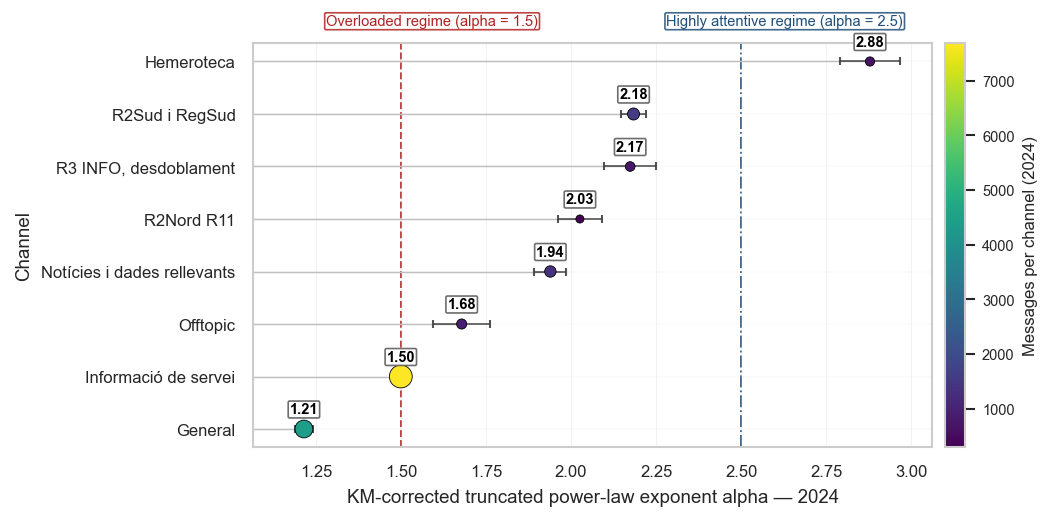

In [13]:
# TPL KM-corrected lollipop — Normal behavior (2024) — paper-ready
alpha_tpl_km_nb = alpha_tpl_df_nb.dropna(subset=['alpha_tpl_km']).sort_values('alpha_tpl_km', ascending=True).reset_index(drop=True)
alpha_tpl_km_nb['channel_label'] = alpha_tpl_km_nb['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

import seaborn as sns
import matplotlib as mpl
sns.set_theme(style='whitegrid', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

fig, ax = plt.subplots(figsize=(7, 3.5))

x0 = max(0, alpha_tpl_km_nb['alpha_tpl_km'].min() - 0.15)
for i, row in alpha_tpl_km_nb.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_tpl_km'], color='0.75', linewidth=0.7, zorder=1)

sizes = np.interp(alpha_tpl_km_nb['n_messages'],
                  (alpha_tpl_km_nb['n_messages'].min(), alpha_tpl_km_nb['n_messages'].max()), (15, 120))
scatter = ax.scatter(alpha_tpl_km_nb['alpha_tpl_km'], np.arange(len(alpha_tpl_km_nb)),
                     s=sizes, c=alpha_tpl_km_nb['n_messages'], cmap='viridis',
                     edgecolor='black', linewidth=0.4, zorder=3)

valid_sigma = alpha_tpl_km_nb['sigma_alpha_km'].notna()
ax.errorbar(alpha_tpl_km_nb.loc[valid_sigma, 'alpha_tpl_km'], np.where(valid_sigma)[0],
            xerr=alpha_tpl_km_nb.loc[valid_sigma, 'sigma_alpha_km'],
            fmt='none', ecolor='0.25', elinewidth=0.8, capsize=2, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=0.9, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=0.9, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_tpl_km_nb) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=7, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.1'))
ax.text(2.28, len(alpha_tpl_km_nb) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=7, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.1'))

ax.set_yticks(np.arange(len(alpha_tpl_km_nb)))
ax.set_yticklabels(alpha_tpl_km_nb['channel_label'], fontsize=8)
ax.set_xlabel('KM-corrected truncated power-law exponent alpha — 2024', fontsize=9)
ax.set_ylabel('Channel', fontsize=9)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.5)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (2024)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

for i, row in alpha_tpl_km_nb.iterrows():
    ax.annotate(f"{row['alpha_tpl_km']:.2f}", (row['alpha_tpl_km'], i),
                xytext=(0, 6), textcoords='offset points',
                va='bottom', ha='center', fontsize=7, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.1'))

fig.savefig('paper_alpha_tpl_km_2024.pdf', format='pdf', bbox_inches='tight')
plt.show()


## Analysis with Emergency behavior (Jan 15, 2026 onwards)

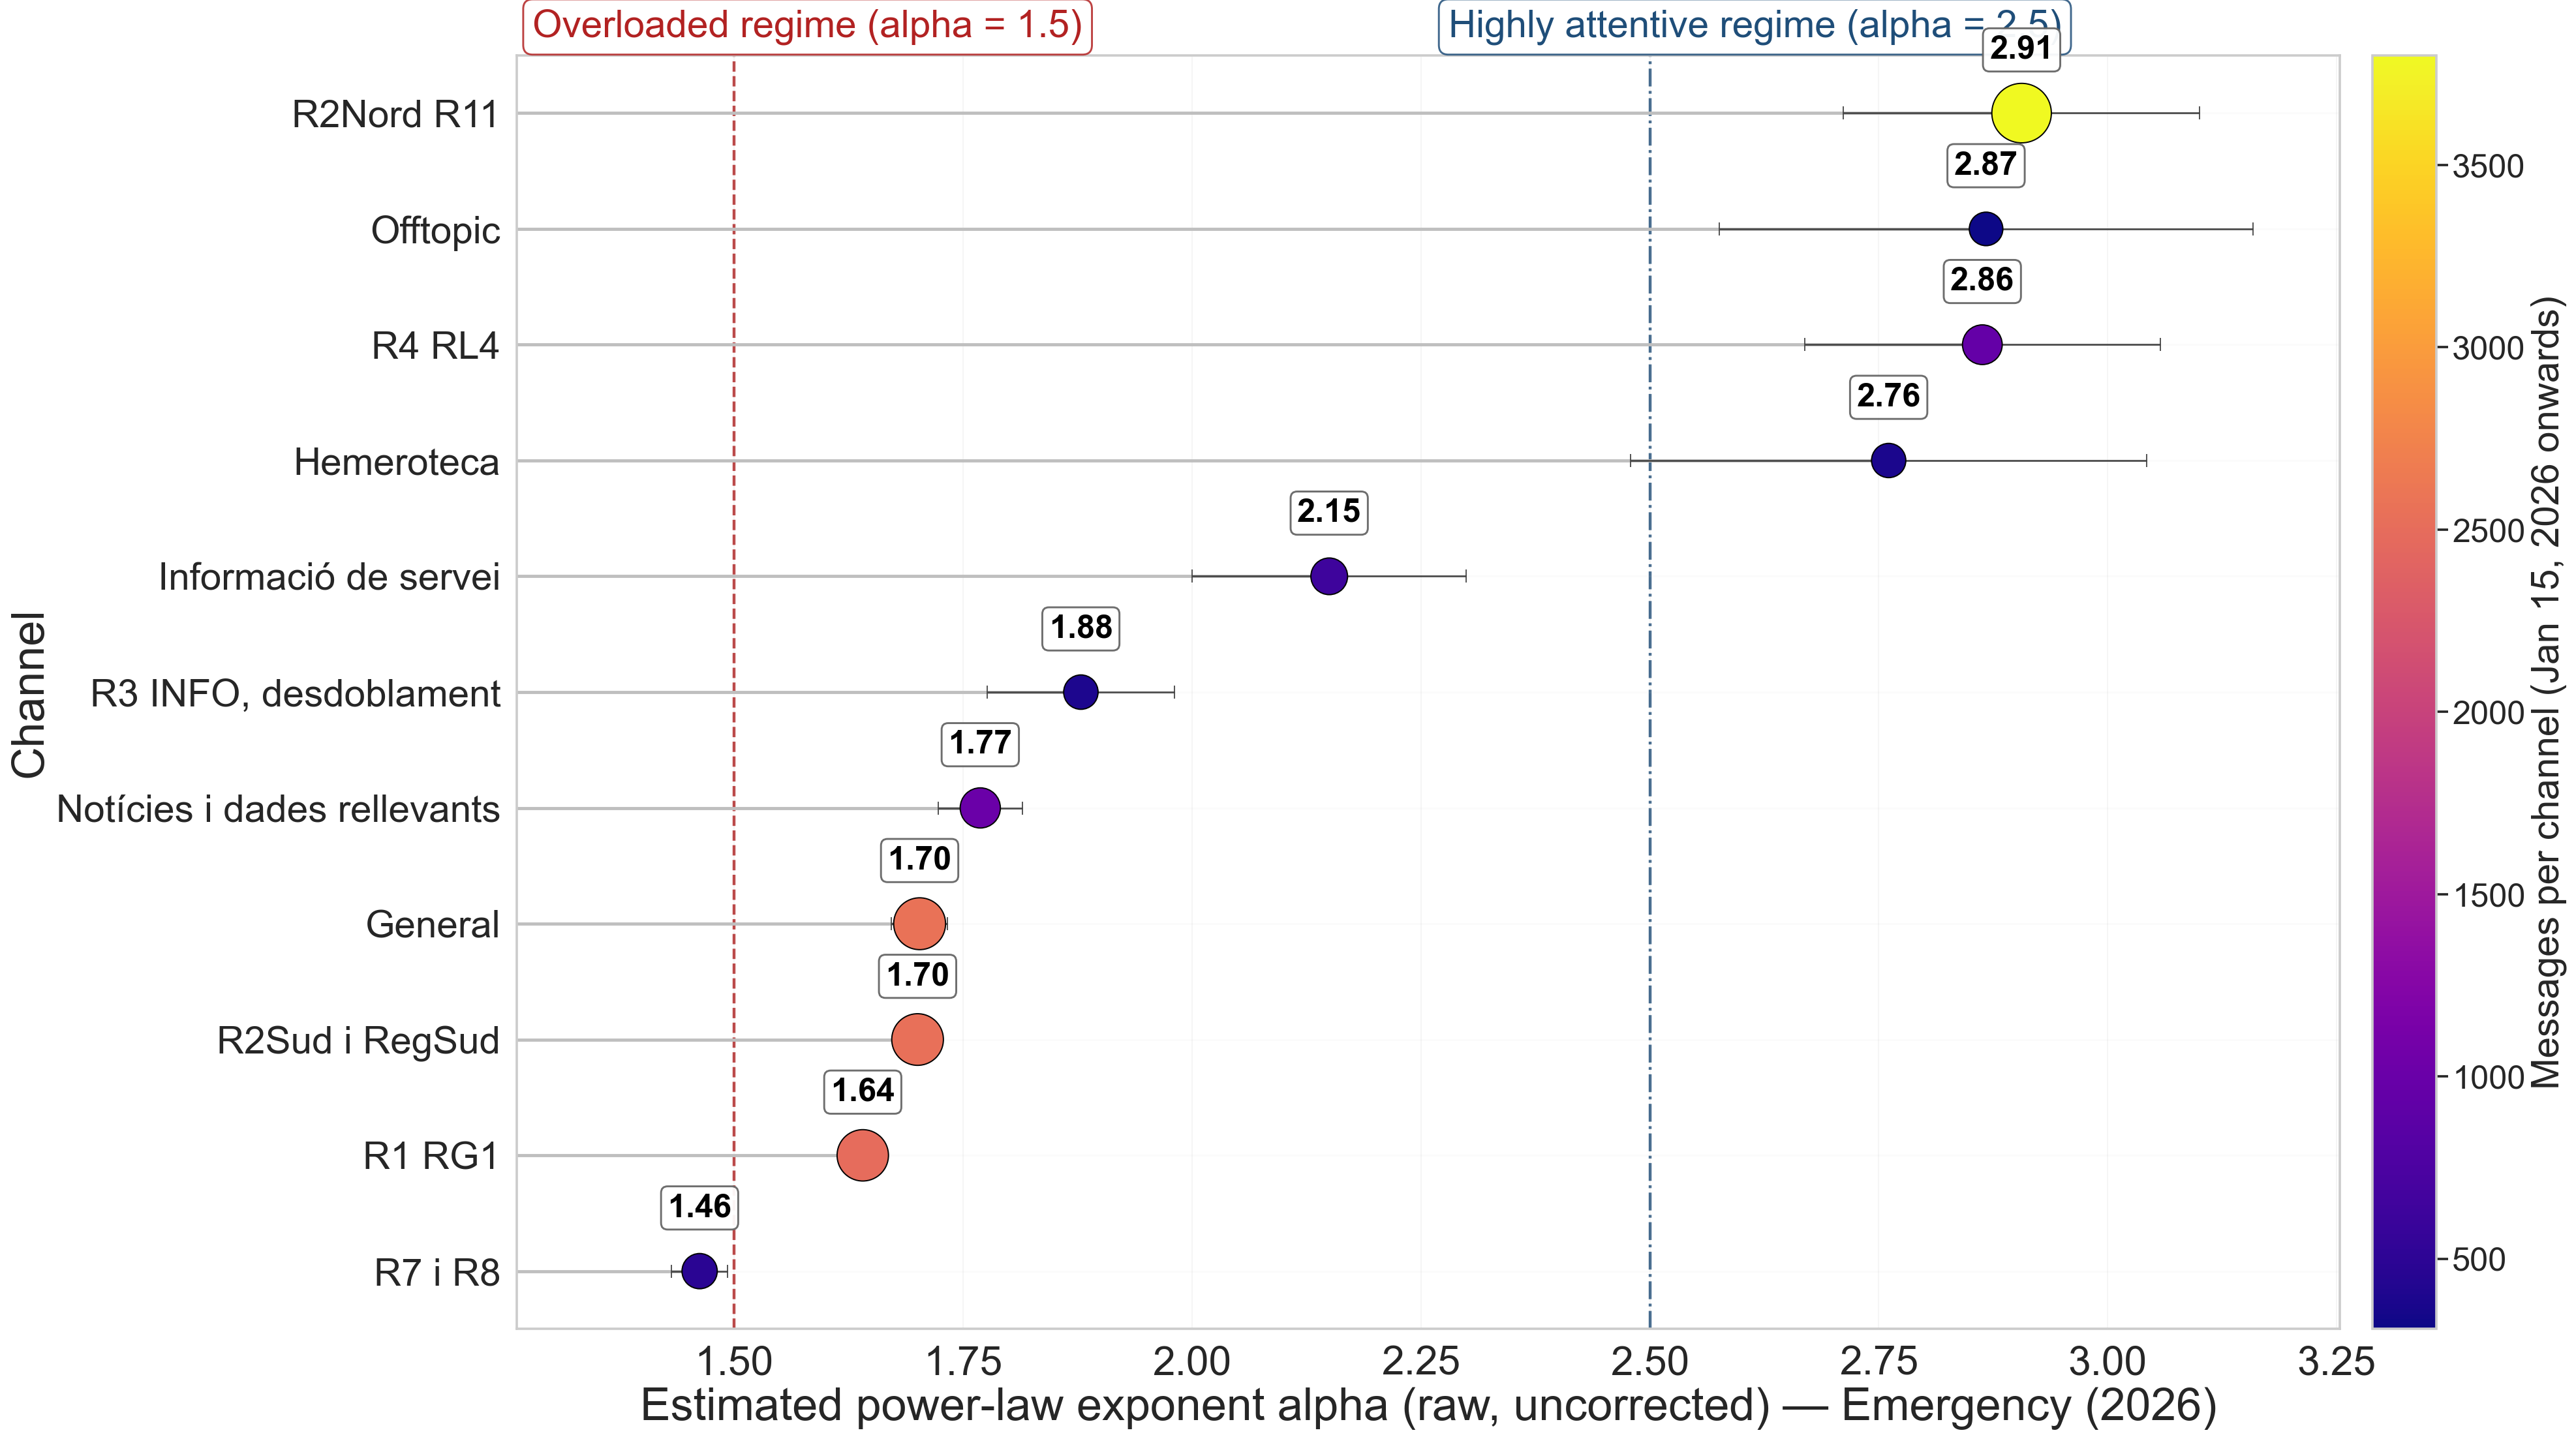

,channel,alpha,alpha_km,bias_sev,sigma,xmin,n_messages,n_waiting,n_tail
0,R7 i R8,1.462272,1.579468,0.1748,0.030548,955.0,475,473,229
1,R1 RG1,1.640449,1.738112,0.0358,0.025296,991.0,2497,2484,641
2,R2Sud i RegSud,1.700308,1.826998,0.0201,0.025027,1159.0,2537,2514,783
3,General,1.702546,1.889903,0.0209,0.030662,1990.0,2570,2547,525
4,Notícies i dades rellevants,1.768780,1.997640,0.0289,0.046192,4988.0,1013,1001,277
5,"R3 INFO, desdoblament",1.878644,2.107162,0.0557,0.102140,24191.0,390,388,74
6,Informació de servei,2.149871,2.337237,0.0592,0.149700,37061.0,625,615,59
7,Hemeroteca,2.760852,3.022657,0.0389,0.281962,73237.0,376,330,39
8,R4 RL4,2.863150,3.121989,0.0257,0.194247,33754.0,959,951,92
9,Offtopic,2.867215,2.825036,0.0578,0.291610,67892.0,307,302,41


<Figure size 896x672 with 0 Axes>

In [14]:
# PL analysis — Emergency behavior (Jan 15, 2026 onwards)
df_eb = df.copy()
df_eb['date'] = pd.to_datetime(df_eb['date'], errors='coerce')
df_eb = df_eb.dropna(subset=['date', 'topic_name'])
tz_eb = df_eb['date'].dt.tz
start_eb = pd.Timestamp('2026-01-15').tz_localize(tz_eb) if tz_eb else pd.Timestamp('2026-01-15')
df_eb = df_eb[df_eb['date'] >= start_eb]
cutoff_eb = df_eb['date'].max()

channel_sizes_eb = df_eb.groupby('topic_name').size().sort_values(ascending=False)
eligible_eb = channel_sizes_eb[channel_sizes_eb > 100].index

results_eb = []
for channel in eligible_eb:
    ch = df_eb.loc[df_eb['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]

    T_seconds = (cutoff_eb - ch['date'].iloc[0]).total_seconds()
    tau_fc    = max((cutoff_eb - ch['date'].iloc[-1]).total_seconds(), 0.0)
    bias_sev  = waiting.max() / T_seconds

    iet_vals = waiting.values
    km_dur   = np.concatenate([iet_vals, iet_vals, [tau_fc]])
    km_obs   = np.concatenate([np.ones(len(iet_vals)), np.ones(len(iet_vals)), [0]])
    kmf = KaplanMeierFitter()
    kmf.fit(km_dur, event_observed=km_obs.astype(bool))

    if len(waiting) < 50:
        continue
    if len(waiting) > 6000:
        waiting = waiting.sample(6000, random_state=42).sort_values()

    try:
        fit   = powerlaw.Fit(waiting.values, discrete=True, verbose=False)
        pl    = fit.power_law
        alpha = float(getattr(pl, 'alpha', np.nan))
        sigma = float(getattr(pl, 'sigma', np.nan))
        xmin  = float(getattr(pl, 'xmin', np.nan))
        n_tail = int(np.sum(waiting.values >= xmin)) if np.isfinite(xmin) else np.nan

        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask = (km_t >= xmin) & (km_s > 0) & (km_t > 0)
        if np.isfinite(xmin) and mask.sum() > 5:
            slope, _ = np.polyfit(np.log(km_t[mask]), np.log(km_s[mask]), 1)
            alpha_km = float(1.0 - slope)
        else:
            alpha_km = np.nan

        if np.isfinite(alpha):
            results_eb.append({
                'channel':    channel,
                'alpha':      alpha,
                'alpha_km':   alpha_km,
                'bias_sev':   round(bias_sev, 4),
                'sigma':      sigma if np.isfinite(sigma) else np.nan,
                'xmin':       xmin,
                'n_messages': int(channel_sizes_eb[channel]),
                'n_waiting':  int(len(waiting)),
                'n_tail':     n_tail
            })
    except Exception as exc:
        print(f"Skipping {channel}: {exc}")

alpha_df_eb = pd.DataFrame(results_eb).sort_values('alpha', ascending=True).reset_index(drop=True)
alpha_df_eb['channel_label'] = alpha_df_eb['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

# PL raw lollipop
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'axes.titlesize': 42, 'axes.labelsize': 36,
    'xtick.labelsize': 32, 'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_df_eb['alpha'].min() - 0.2)
for i, row in alpha_df_eb.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(alpha_df_eb['n_messages'],
                  (alpha_df_eb['n_messages'].min(), alpha_df_eb['n_messages'].max()), (700, 2200))
scatter = ax.scatter(alpha_df_eb['alpha'], np.arange(len(alpha_df_eb)),
                     s=sizes, c=alpha_df_eb['n_messages'], cmap='plasma',
                     edgecolor='black', linewidth=1.0, zorder=3)

valid_sigma = alpha_df_eb['sigma'].notna()
ax.errorbar(alpha_df_eb.loc[valid_sigma, 'alpha'], np.where(valid_sigma)[0],
            xerr=alpha_df_eb.loc[valid_sigma, 'sigma'],
            fmt='none', ecolor='0.25', elinewidth=1.5, capsize=5, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_df_eb) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25'))
ax.text(2.28, len(alpha_df_eb) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25'))

ax.set_yticks(np.arange(len(alpha_df_eb)))
ax.set_yticklabels(alpha_df_eb['channel_label'], fontsize=30)
ax.set_xlabel('Estimated power-law exponent alpha (raw, uncorrected) — Emergency (2026)', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (Jan 15, 2026 onwards)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_df_eb.iterrows():
    ax.annotate(f"{row['alpha']:.2f}", (row['alpha'], i),
                xytext=(0, 38), textcoords='offset points',
                va='bottom', ha='center', fontsize=26, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.savefig('alpha_pl_eb_poster.svg', format='svg', bbox_inches='tight')

alpha_df_eb[['channel', 'alpha', 'alpha_km', 'bias_sev', 'sigma', 'xmin', 'n_messages', 'n_waiting', 'n_tail']]

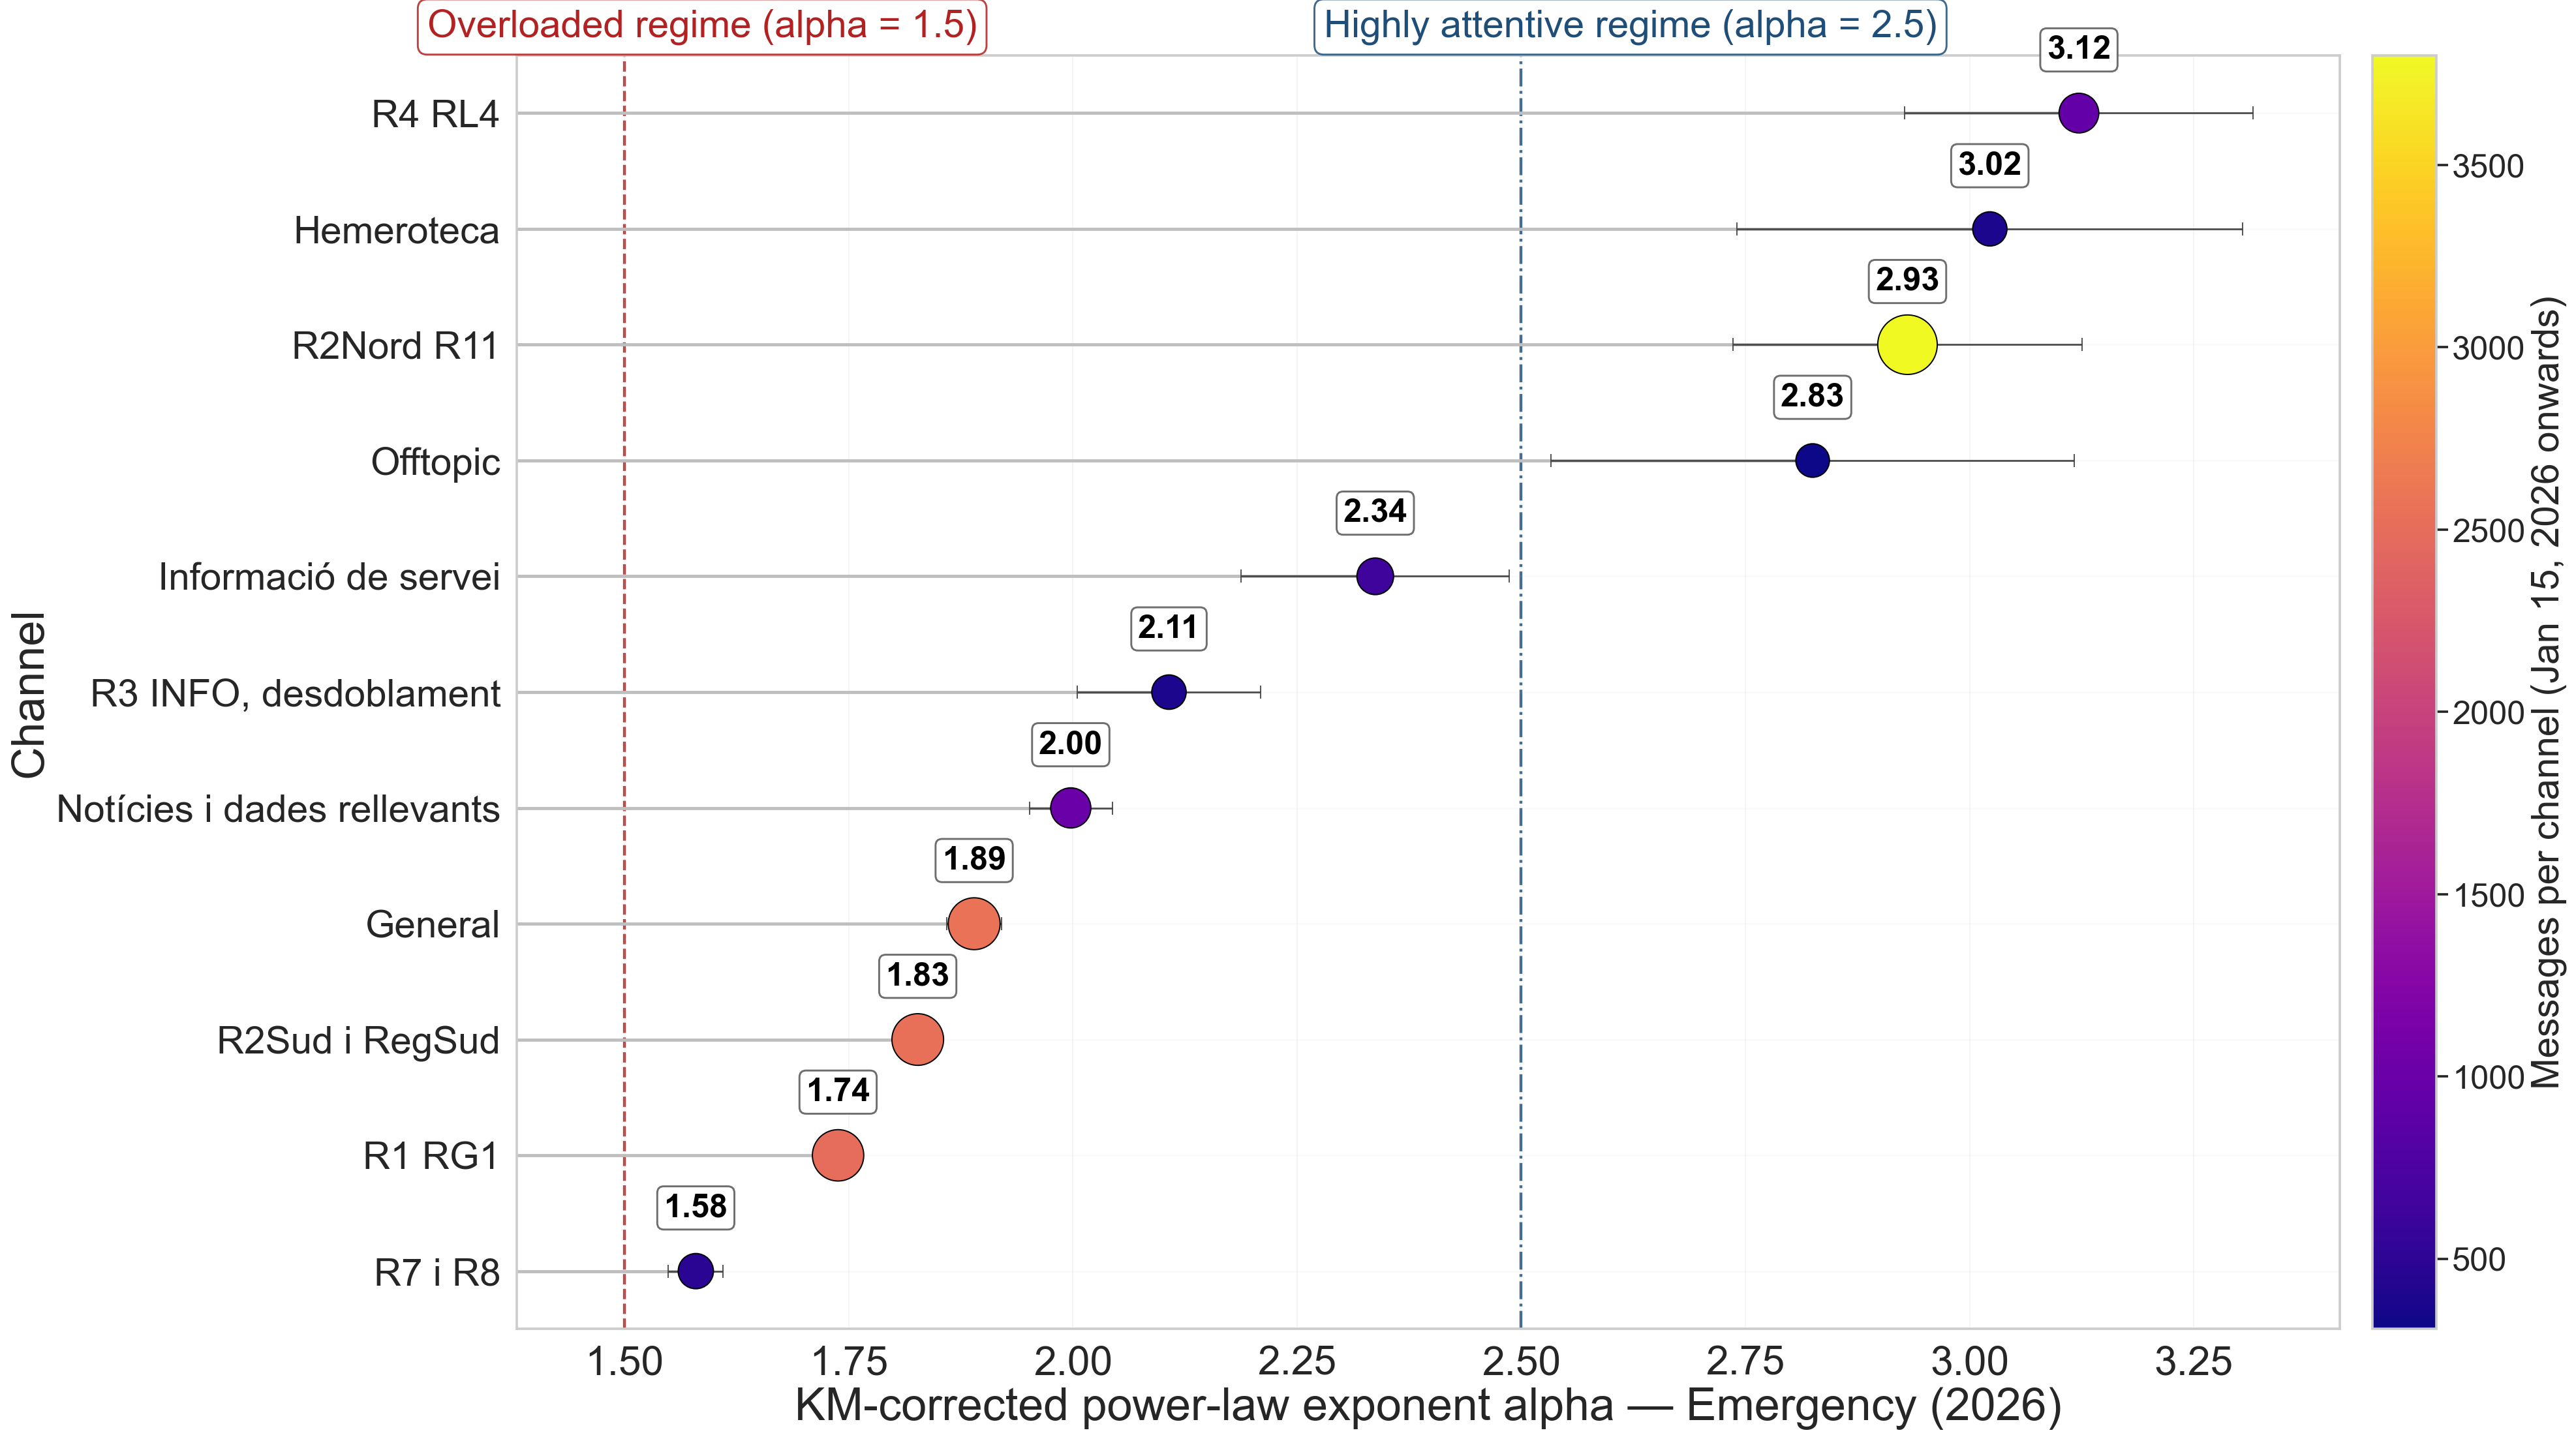

<Figure size 896x672 with 0 Axes>

In [15]:
# PL KM-corrected lollipop — Emergency behavior (2026)
alpha_km_eb = alpha_df_eb.dropna(subset=['alpha_km']).sort_values('alpha_km', ascending=True).reset_index(drop=True)
alpha_km_eb['channel_label'] = alpha_km_eb['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'axes.titlesize': 42, 'axes.labelsize': 36,
    'xtick.labelsize': 32, 'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_km_eb['alpha_km'].min() - 0.2)
for i, row in alpha_km_eb.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_km'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(alpha_km_eb['n_messages'],
                  (alpha_km_eb['n_messages'].min(), alpha_km_eb['n_messages'].max()), (700, 2200))
scatter = ax.scatter(alpha_km_eb['alpha_km'], np.arange(len(alpha_km_eb)),
                     s=sizes, c=alpha_km_eb['n_messages'], cmap='plasma',
                     edgecolor='black', linewidth=1.0, zorder=3)

valid_sigma = alpha_km_eb['sigma'].notna()
ax.errorbar(alpha_km_eb.loc[valid_sigma, 'alpha_km'], np.where(valid_sigma)[0],
            xerr=alpha_km_eb.loc[valid_sigma, 'sigma'],
            fmt='none', ecolor='0.25', elinewidth=1.5, capsize=5, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_km_eb) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25'))
ax.text(2.28, len(alpha_km_eb) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25'))

ax.set_yticks(np.arange(len(alpha_km_eb)))
ax.set_yticklabels(alpha_km_eb['channel_label'], fontsize=30)
ax.set_xlabel('KM-corrected power-law exponent alpha — Emergency (2026)', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (Jan 15, 2026 onwards)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_km_eb.iterrows():
    ax.annotate(f"{row['alpha_km']:.2f}", (row['alpha_km'], i),
                xytext=(0, 38), textcoords='offset points',
                va='bottom', ha='center', fontsize=26, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.savefig('alpha_km_eb_poster.svg', format='svg', bbox_inches='tight')

### Truncated power law (emergency behavior)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

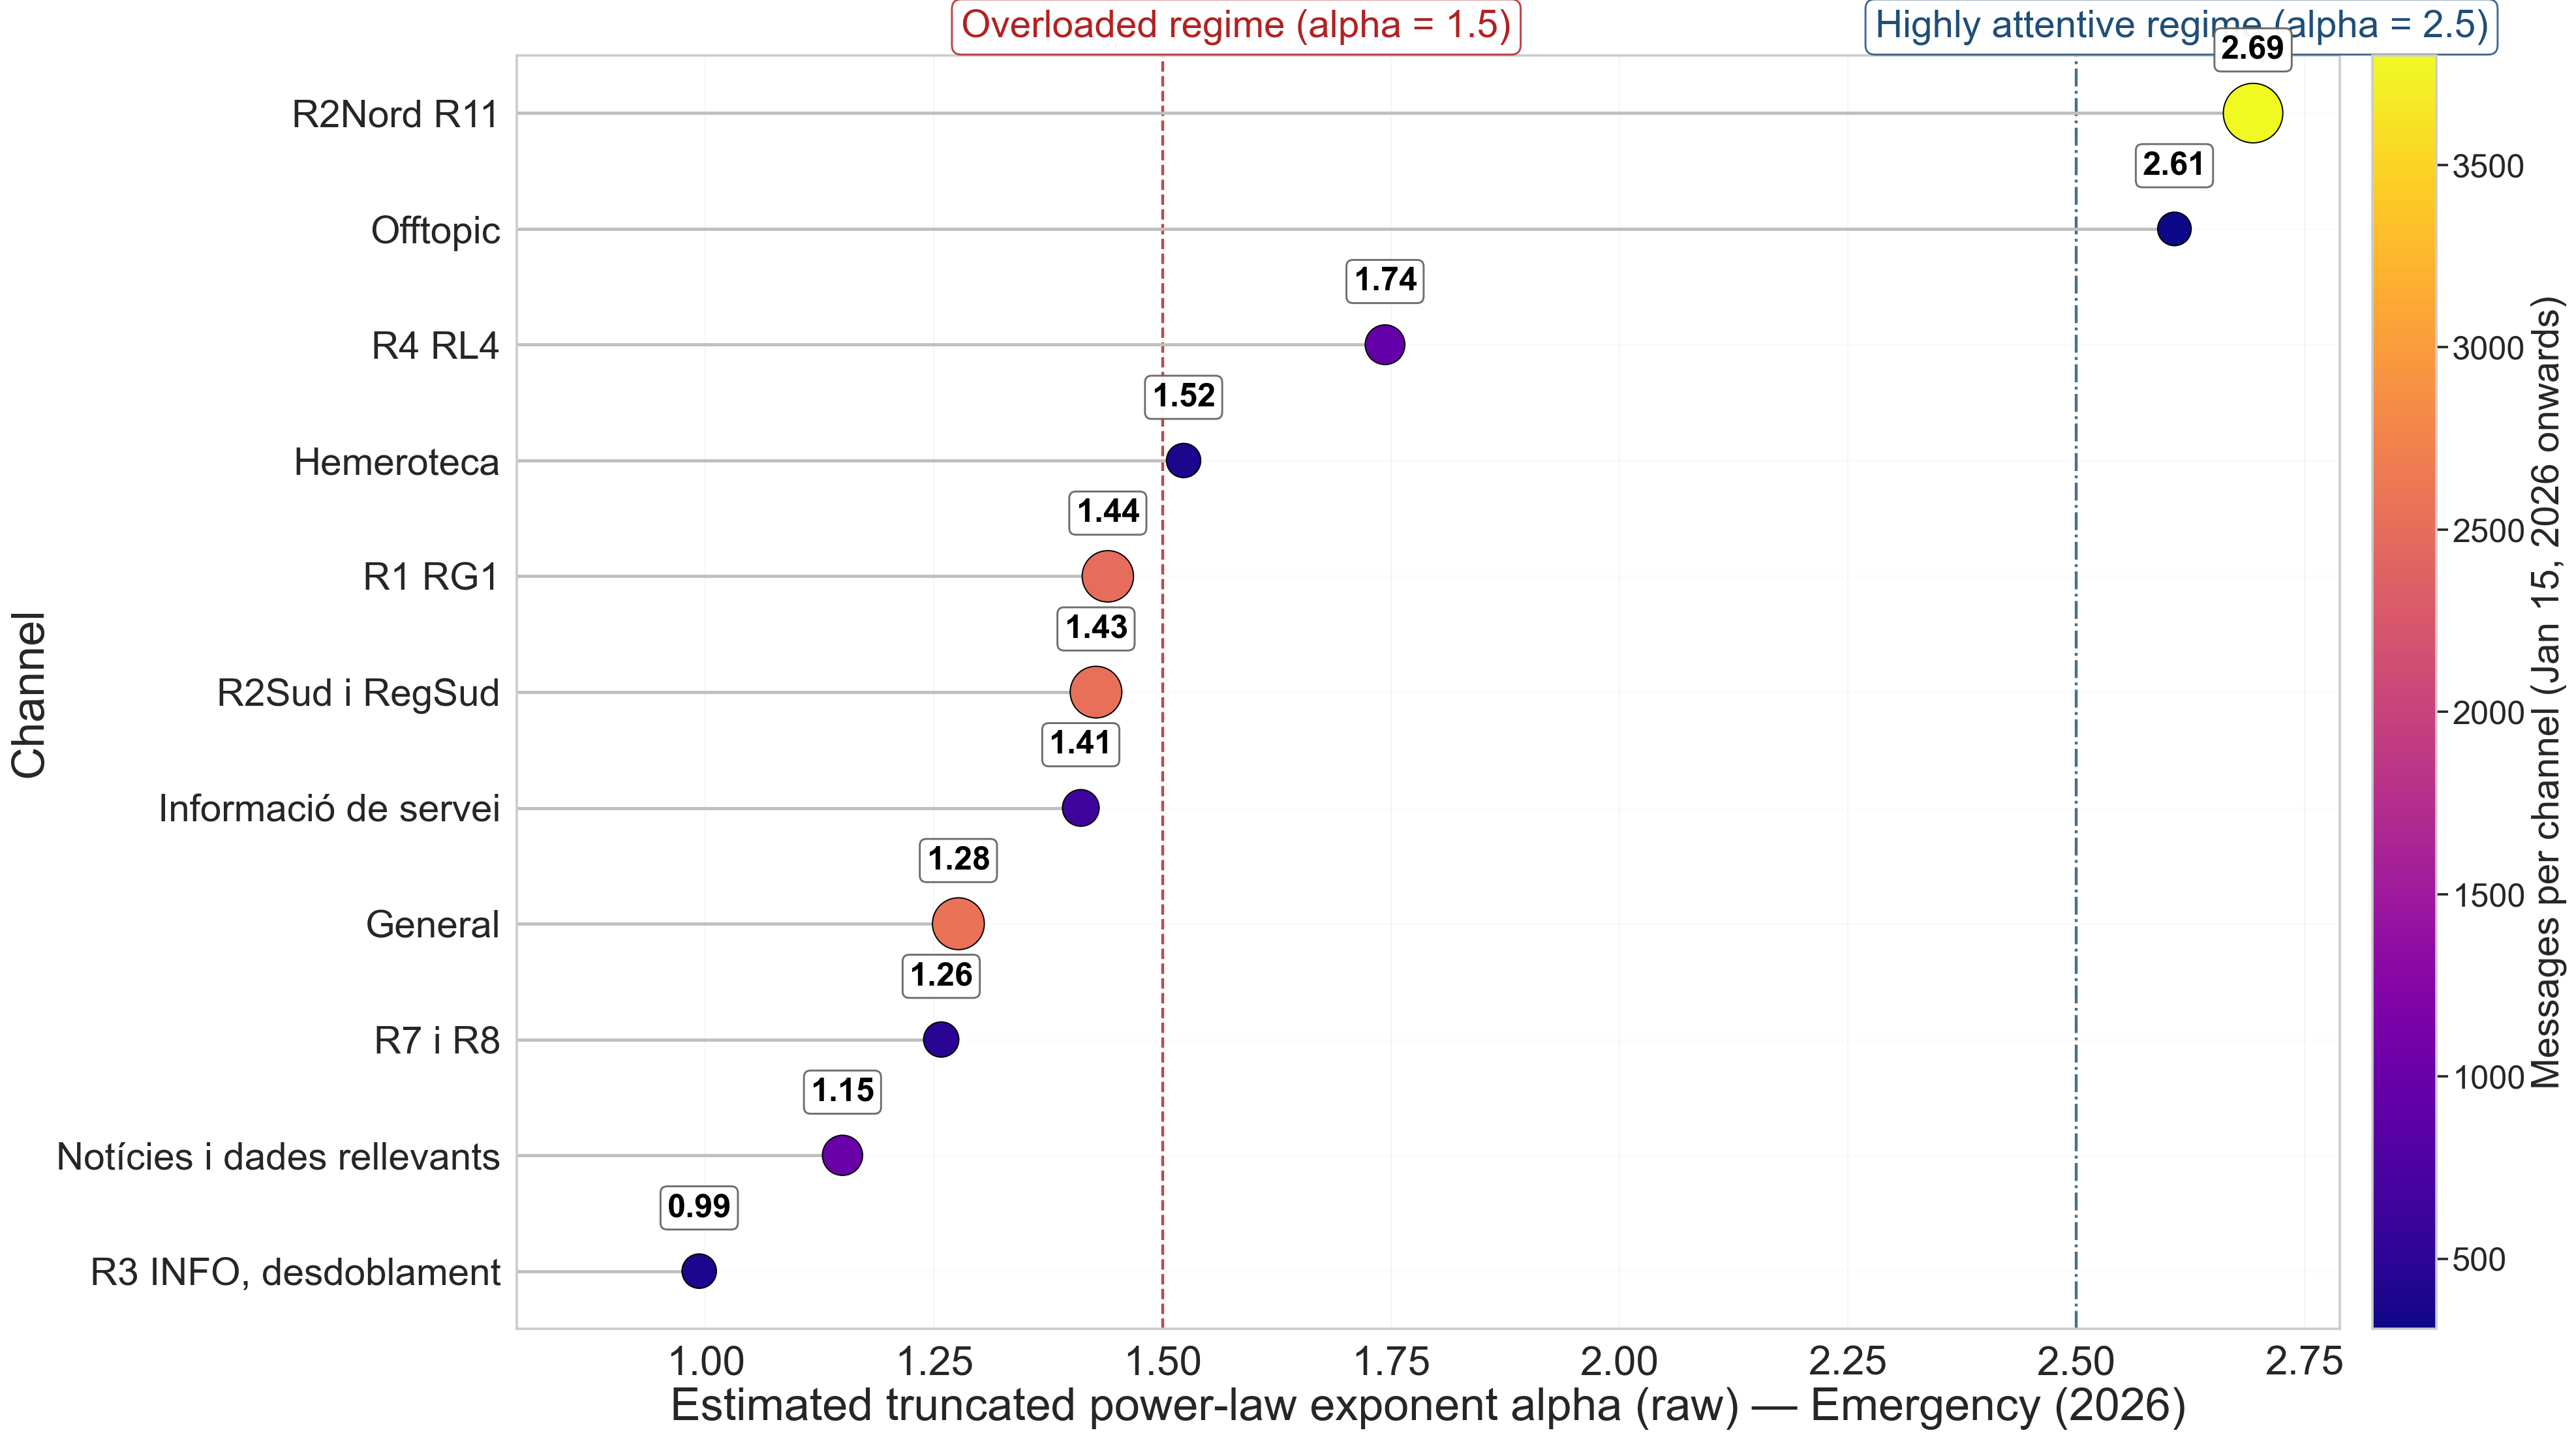

,channel,alpha_tpl,alpha_tpl_km,lambda_tpl_km,bias_sev,sigma_tpl,sigma_alpha_km,xmin,n_messages,n_waiting,n_tail
0,"R3 INFO, desdoblament",0.992986,1.445452,5.597378e-06,0.0557,NaN,0.016227,24191.0,390,388,74
1,Notícies i dades rellevants,1.149824,1.477140,1.480502e-05,0.0289,NaN,0.004664,4988.0,1013,1001,277
2,R7 i R8,1.257889,1.351256,8.540198e-06,0.1748,NaN,0.001447,955.0,475,473,229
3,General,1.276687,1.484027,2.304213e-05,0.0209,NaN,0.001327,1990.0,2570,2547,525
4,Informació de servei,1.410676,1.799381,3.688089e-06,0.0592,NaN,0.043390,37061.0,625,615,59
5,R2Sud i RegSud,1.427340,1.591161,1.367891e-05,0.0201,NaN,0.001337,1159.0,2537,2514,783
6,R1 RG1,1.440261,1.562004,7.771151e-06,0.0358,NaN,0.001619,991.0,2497,2484,641
7,Hemeroteca,1.523187,2.575859,3.773474e-07,0.0389,NaN,0.132786,73237.0,376,330,39
8,R4 RL4,1.743692,1.951468,1.625184e-05,0.0257,NaN,0.068741,33754.0,959,951,92
9,Offtopic,2.607753,2.890147,1.061795e-22,0.0578,NaN,0.107995,67892.0,307,302,41


<Figure size 896x672 with 0 Axes>

In [16]:
# TPL analysis — Emergency behavior (Jan 15, 2026 onwards)
from scipy.optimize import curve_fit

results_tpl_eb = []
for channel in eligible_eb:
    ch = df_eb.loc[df_eb['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]

    T_seconds = (cutoff_eb - ch['date'].iloc[0]).total_seconds()
    tau_fc    = max((cutoff_eb - ch['date'].iloc[-1]).total_seconds(), 0.0)
    bias_sev  = waiting.max() / T_seconds

    iet_vals = waiting.values
    km_dur   = np.concatenate([iet_vals, iet_vals, [tau_fc]])
    km_obs   = np.concatenate([np.ones(len(iet_vals)), np.ones(len(iet_vals)), [0]])
    kmf = KaplanMeierFitter()
    kmf.fit(km_dur, event_observed=km_obs.astype(bool))

    if len(waiting) < 50:
        continue
    if len(waiting) > 6000:
        waiting = waiting.sample(6000, random_state=42).sort_values()

    try:
        fit        = powerlaw.Fit(waiting.values, discrete=True, verbose=False)
        tpl        = fit.truncated_power_law
        alpha_tpl  = float(getattr(tpl, 'alpha', np.nan))
        sigma_tpl  = float(getattr(tpl, 'sigma', np.nan))
        xmin       = float(getattr(tpl, 'xmin', np.nan))
        n_tail     = int(np.sum(waiting.values >= xmin)) if np.isfinite(xmin) else np.nan

        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask = (km_t >= xmin) & (km_s > 0) & (km_t > 0)

        alpha_tpl_km  = np.nan
        lambda_tpl_km = np.nan
        sigma_alpha_km = np.nan
        if np.isfinite(xmin) and mask.sum() > 5:
            km_t_tail = km_t[mask]
            km_s_norm = km_s[mask] / km_s[mask][0]

            def tpl_surv(t, alpha, lam):
                return (t / xmin) ** (-(alpha - 1)) * np.exp(-(t - xmin) * lam)

            try:
                popt, pcov = curve_fit(
                    tpl_surv, km_t_tail, km_s_norm,
                    p0=[max(alpha_tpl, 1.01), 1.0 / iet_vals.max()],
                    bounds=([1.001, 0.0], [20.0, np.inf]),
                    maxfev=10000
                )
                alpha_tpl_km, lambda_tpl_km = float(popt[0]), float(popt[1])
                sigma_alpha_km = float(np.sqrt(pcov[0, 0])) if np.isfinite(pcov[0, 0]) else np.nan
            except Exception:
                pass

        if np.isfinite(alpha_tpl):
            results_tpl_eb.append({
                'channel':       channel,
                'alpha_tpl':     alpha_tpl,
                'alpha_tpl_km':  alpha_tpl_km,
                'lambda_tpl_km': lambda_tpl_km,
                'bias_sev':      round(bias_sev, 4),
                'sigma_tpl':     sigma_tpl if np.isfinite(sigma_tpl) else np.nan,
                'sigma_alpha_km': sigma_alpha_km,
                'xmin':          xmin,
                'n_messages':    int(channel_sizes_eb[channel]),
                'n_waiting':     int(len(waiting)),
                'n_tail':        n_tail
            })
    except Exception as exc:
        print(f"Skipping {channel}: {exc}")

alpha_tpl_df_eb = pd.DataFrame(results_tpl_eb).sort_values('alpha_tpl', ascending=True).reset_index(drop=True)
alpha_tpl_df_eb['channel_label'] = alpha_tpl_df_eb['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

# TPL raw lollipop
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'axes.titlesize': 42, 'axes.labelsize': 36,
    'xtick.labelsize': 32, 'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_tpl_df_eb['alpha_tpl'].min() - 0.2)
for i, row in alpha_tpl_df_eb.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_tpl'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(alpha_tpl_df_eb['n_messages'],
                  (alpha_tpl_df_eb['n_messages'].min(), alpha_tpl_df_eb['n_messages'].max()), (700, 2200))
scatter = ax.scatter(alpha_tpl_df_eb['alpha_tpl'], np.arange(len(alpha_tpl_df_eb)),
                     s=sizes, c=alpha_tpl_df_eb['n_messages'], cmap='plasma',
                     edgecolor='black', linewidth=1.0, zorder=3)

valid_sigma = alpha_tpl_df_eb['sigma_tpl'].notna()
ax.errorbar(alpha_tpl_df_eb.loc[valid_sigma, 'alpha_tpl'], np.where(valid_sigma)[0],
            xerr=alpha_tpl_df_eb.loc[valid_sigma, 'sigma_tpl'],
            fmt='none', ecolor='0.25', elinewidth=1.5, capsize=5, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_tpl_df_eb) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25'))
ax.text(2.28, len(alpha_tpl_df_eb) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25'))

ax.set_yticks(np.arange(len(alpha_tpl_df_eb)))
ax.set_yticklabels(alpha_tpl_df_eb['channel_label'], fontsize=30)
ax.set_xlabel('Estimated truncated power-law exponent alpha (raw) — Emergency (2026)', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (Jan 15, 2026 onwards)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_tpl_df_eb.iterrows():
    ax.annotate(f"{row['alpha_tpl']:.2f}", (row['alpha_tpl'], i),
                xytext=(0, 38), textcoords='offset points',
                va='bottom', ha='center', fontsize=26, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.savefig('alpha_tpl_eb_poster.svg', format='svg', bbox_inches='tight')

alpha_tpl_df_eb[['channel', 'alpha_tpl', 'alpha_tpl_km', 'lambda_tpl_km', 'bias_sev', 'sigma_tpl', 'sigma_alpha_km', 'xmin', 'n_messages', 'n_waiting', 'n_tail']]

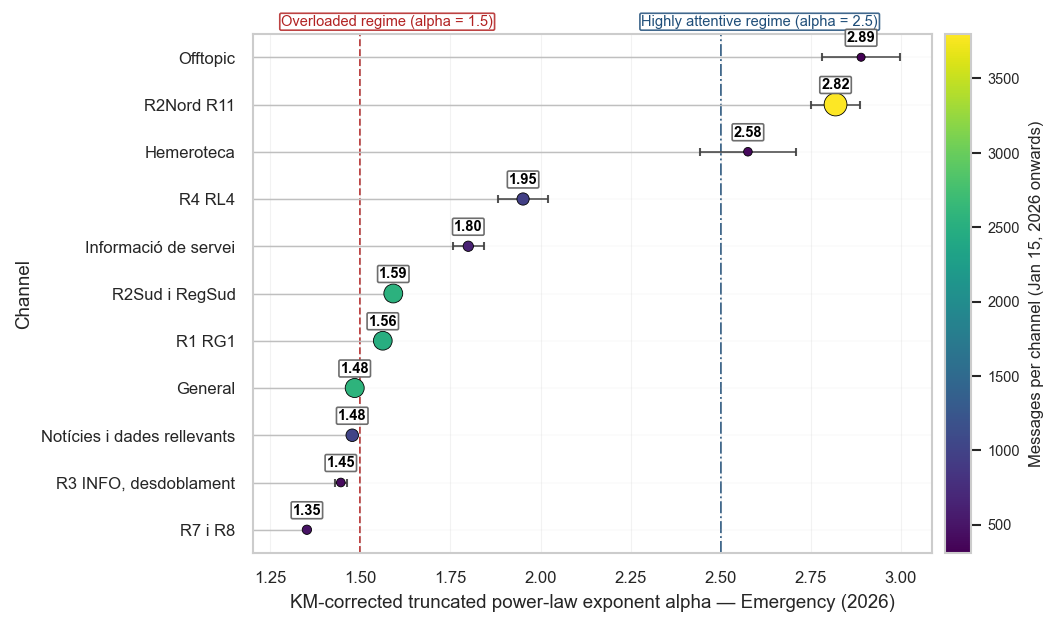

In [17]:
# TPL KM-corrected lollipop — Emergency behavior (2026) — paper-ready
alpha_tpl_km_eb = alpha_tpl_df_eb.dropna(subset=['alpha_tpl_km']).sort_values('alpha_tpl_km', ascending=True).reset_index(drop=True)
alpha_tpl_km_eb['channel_label'] = alpha_tpl_km_eb['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

import seaborn as sns
import matplotlib as mpl
sns.set_theme(style='whitegrid', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

fig, ax = plt.subplots(figsize=(7, 4.5))

x0 = max(0, alpha_tpl_km_eb['alpha_tpl_km'].min() - 0.15)
for i, row in alpha_tpl_km_eb.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_tpl_km'], color='0.75', linewidth=0.7, zorder=1)

sizes = np.interp(alpha_tpl_km_eb['n_messages'],
                  (alpha_tpl_km_eb['n_messages'].min(), alpha_tpl_km_eb['n_messages'].max()), (15, 120))
scatter = ax.scatter(alpha_tpl_km_eb['alpha_tpl_km'], np.arange(len(alpha_tpl_km_eb)),
                     s=sizes, c=alpha_tpl_km_eb['n_messages'], cmap='viridis',
                     edgecolor='black', linewidth=0.4, zorder=3)

valid_sigma = alpha_tpl_km_eb['sigma_alpha_km'].notna()
ax.errorbar(alpha_tpl_km_eb.loc[valid_sigma, 'alpha_tpl_km'], np.where(valid_sigma)[0],
            xerr=alpha_tpl_km_eb.loc[valid_sigma, 'sigma_alpha_km'],
            fmt='none', ecolor='0.25', elinewidth=0.8, capsize=2, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=0.9, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=0.9, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_tpl_km_eb) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=7, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.1'))
ax.text(2.28, len(alpha_tpl_km_eb) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=7, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.1'))

ax.set_yticks(np.arange(len(alpha_tpl_km_eb)))
ax.set_yticklabels(alpha_tpl_km_eb['channel_label'], fontsize=8)
ax.set_xlabel('KM-corrected truncated power-law exponent alpha — Emergency (2026)', fontsize=9)
ax.set_ylabel('Channel', fontsize=9)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.5)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (Jan 15, 2026 onwards)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

for i, row in alpha_tpl_km_eb.iterrows():
    ax.annotate(f"{row['alpha_tpl_km']:.2f}", (row['alpha_tpl_km'], i),
                xytext=(0, 6), textcoords='offset points',
                va='bottom', ha='center', fontsize=7, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.1'))

fig.savefig('paper_alpha_tpl_km_2026.pdf', format='pdf', bbox_inches='tight')
plt.show()
